# Diversity Metrics on WritingPrompts Generations (storytelling_n200)

Applies all six `metrics_lib` metrics to the WritingPrompts story generations in `data_generation/generations/storytelling_n200`:
- 4 open-weight instruction-tuned LLMs x 200 prompts x 5 samples each
- Plus 5 human reference stories per prompt (randomly drawn with a fixed seed from the 5-45 available, so every group has the same size)

**Metrics (from `metrics_lib`):**

| Metric | Function | Level |
|---|---|---|
| D_sem | `semantic_diversity` | group (same prompt, same source, multiple samples) |
| D_lex | `lexical_diversity` | group |
| D_syn | `syntactic_diversity` | group |
| D_disc | `discourse_diversity` | group |
| D_narr | `narrative_diversity` | group |
| D_style | `stylistic_diversity` | whole batch (normalized across all groups at once) |
| DIV | `diversity_score` | single text |
| Perplexity | `compute_perplexity` | single text |
| Coherence | `compute_coherence` | single text |
| Q*Text | `compute_qstar` | single text |

- "group": all samples for one source (model or human) and one prompt
- Group-level metrics need >= 2 texts per group (always true for LLMs and Humans)
- Data loading, quality filter (model: truncation / language drift, human: language drift + exact-duplicate) and the human 5-per-prompt cap all come from `common/data_prep.py`

In [76]:
# Load libraries
import json
import time
import pathlib
import sys
import warnings
from itertools import combinations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, spearmanr
from statsmodels.stats.multitest import multipletests
from tqdm.auto import tqdm

tqdm.pandas()

In [77]:
# Repo root (containing metrics_lib/) importable regardless of the kernel's working directory

def find_repo_root(start=None):
    start = pathlib.Path(start or pathlib.Path.cwd())
    for p in [start, *start.parents]:
        if (p / 'metrics' / 'metrics_lib').is_dir() and (p / 'data_generation' / 'generations' / 'storytelling_n200').is_dir():
            return p
    raise FileNotFoundError("Could not locate the repo root (expected 'metrics/metrics_lib/' and "
                             "'data_generation/generations/storytelling_n200/')")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# metrics_lib
from metrics.metrics_lib import (
    semantic_diversity, lexical_diversity, syntactic_diversity,
    discourse_diversity, narrative_diversity, stylistic_diversity,
)
from metrics.metrics_lib.baseline import (
    diversity_score, compute_perplexity, compute_coherence, compute_qstar, DEFAULT_MODEL_NAME,
)

# Short tag for cache/output filenames tied to the scorer (e.g. 'opt-2.7b'), so switching
# DEFAULT_MODEL_NAME in metrics_lib.baseline can never silently reuse another model's cached scores
MODEL_TAG = DEFAULT_MODEL_NAME.split('/')[-1]

print(f'REPO_ROOT: {REPO_ROOT}')
print(f'Baseline scorer (Perplexity/Coherence): {DEFAULT_MODEL_NAME}')
print('metrics_lib functions loaded: semantic_diversity, lexical_diversity, syntactic_diversity, '
      'discourse_diversity, narrative_diversity, stylistic_diversity, diversity_score, '
      'compute_perplexity, compute_coherence, compute_qstar')

REPO_ROOT: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity
Baseline scorer (Perplexity/Coherence): facebook/opt-2.7b
metrics_lib functions loaded: semantic_diversity, lexical_diversity, syntactic_diversity, discourse_diversity, narrative_diversity, stylistic_diversity, diversity_score, compute_perplexity, compute_coherence, compute_qstar


In [78]:
# Plotting parameters
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})
sns.set_theme(style='whitegrid')

# Repo directories
DATA_DIR = REPO_ROOT / 'data_generation' / 'generations' / 'storytelling_n200'
CACHE_DIR = REPO_ROOT / 'metrics' / '06_writingprompts_diversity' / 'cache'
TABLES_DIR = REPO_ROOT / 'metrics' / '06_writingprompts_diversity' / 'tables'
FIG_DIR = REPO_ROOT / 'figures' / 'writingprompts_diversity'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Shared model constants (common/constants.py)
from common import MODELS, MODEL_LABELS, MODEL_COLORS, MODEL_ORDER, GEN_ORDER

METRIC_LABELS = {
    'D_sem': 'Semantic (Nomic cosine dist.)',
    'D_lex': 'Lexical (unigram Jaccard)',
    'D_syn': 'Syntactic (POS-bigram Jaccard)',
    'D_disc': 'Discourse (entity-grid JSD)',
    'D_narr': 'Narrative (sentiment-arc L2)',
    'D_style': 'Stylistic (7 features + function words)',
    'DIV': 'Diversity (n-gram repetition rate)',
    'Perplexity': f'Perplexity ({MODEL_TAG})',
    'Coherence': f'Coherence (log-prob | prompt, {MODEL_TAG})',
    'QStarText': 'Q*Text (0-100)',
}

GROUP_METRICS = ['D_sem', 'D_lex', 'D_syn', 'D_disc', 'D_narr', 'D_style']
BASELINE_METRICS = ['DIV', 'Perplexity', 'Coherence', 'QStarText']
ALL_METRICS = GROUP_METRICS + BASELINE_METRICS

print(f'DATA_DIR:   {DATA_DIR}')
print(f'CACHE_DIR:  {CACHE_DIR}')
print(f'TABLES_DIR: {TABLES_DIR}')
print(f'FIG_DIR:    {FIG_DIR}')

DATA_DIR:   /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/data_generation/generations/storytelling_n200
CACHE_DIR:  /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/metrics/06_writingprompts_diversity/cache
TABLES_DIR: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/metrics/06_writingprompts_diversity/tables
FIG_DIR:    /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/writingprompts_diversity


## Load & Filter Data

In [79]:
import sys
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from common import data_prep

# Canonical load + quality filter (model: truncation / language drift; human: language drift +
# exact-duplicate) + human 5-cap per prompt (seed data_prep.HUMAN_SAMPLE_SEED)
_df = (data_prep.load_texts('storytelling_n200', n_prompts=200)
       .drop(columns=['domain', 'prompt_id'])
       .rename(columns={'source': 'model_key', 'raw_prompt_id': 'prompt_id',
                        'story_id': 'sample_idx', 'text': 'story'}))



_cols = ['model_key', 'model', 'prompt_id', 'sample_idx', 'prompt', 'story']
df_gen = _df[_df.model_key != 'human'][_cols].reset_index(drop=True)
df_human = _df[_df.model_key == 'human'][_cols].reset_index(drop=True)

# Human groups keyed by raw prompt_id (used to build texts_by_group below)
human_stories_by_prompt = {pid: g['story'].tolist() for pid, g in df_human.groupby('prompt_id')}

print(f'Generated stories: {len(df_gen)}  {df_gen.model.value_counts().reindex(GEN_ORDER).to_dict()}')
print(f'Human references: {len(df_human)} across {df_human.prompt_id.nunique()} prompts '
      f'(5-cap/prompt, seed {data_prep.HUMAN_SAMPLE_SEED})')

Generated stories: 3973  {'Gemma-2-9B': 1000, 'Llama-3.1-8B': 996, 'Mistral-7B-v0.3': 985, 'Qwen2.5-7B': 992}
Human references: 999 across 200 prompts (5-cap/prompt, seed 20260902)


In [80]:
# Fingerprint the exact loaded text rows so a corpus change (quality filter, human 5-cap,
# sample seed) forces fresh caches everywhere below instead of silently reusing stale
# per-group/per-story values under an unchanged group_id / (model_key, prompt_id, sample_idx) key

DATA_FINGERPRINT = data_prep.dataframe_fingerprint(
    _df, cols=['model_key', 'prompt_id', 'sample_idx', 'story'])


print(f'Dataset fingerprint: {DATA_FINGERPRINT}')

Dataset fingerprint: 91dcf638d38fe62b


In [81]:
# Model quality filter and human 5-cap are already applied by common/data_prep.py 

group_sizes = df_gen.groupby(['model', 'prompt_id']).size()

print('Stories per model:')
print(df_gen['model'].value_counts().reindex(GEN_ORDER))
print('\nGroup-size distribution (samples per model x prompt):')
print(group_sizes.value_counts().sort_index())
print(f'Model groups with < 2 samples (cannot compute group diversity): {(group_sizes < 2).sum()}')

Stories per model:
model
Gemma-2-9B         1000
Llama-3.1-8B        996
Mistral-7B-v0.3     985
Qwen2.5-7B          992
Name: count, dtype: int64

Group-size distribution (samples per model x prompt):
2      1
4     24
5    775
Name: count, dtype: int64
Model groups with < 2 samples (cannot compute group diversity): 0


## Build Prompt Groups

A group is `(source, prompt_id)` -> list of story texts, where source is one of the 4 LLMs or `human`

In [82]:
# group_id = 'source/prompt_id' -> list of story texts (only groups with >= 2 samples are usable)
texts_by_group = {}
for (model_key, prompt_id), g in df_gen.groupby(['model_key', 'prompt_id']):
    if len(g) >= 2:
        texts_by_group[f'{model_key}/{prompt_id}'] = g['story'].tolist()

# Human groups: only prompts with >= 2 distinct human-written stories in the source corpus
for prompt_id, stories in human_stories_by_prompt.items():
    if len(stories) >= 2:
        texts_by_group[f'human/{prompt_id}'] = stories

group_ids = list(texts_by_group.keys())
n_human_groups = sum(1 for gid in group_ids if gid.startswith('human/'))

print(f'{len(group_ids)} usable groups (source x prompt) with >= 2 samples, of which {n_human_groups} are human')
print(f'Total texts across groups: {sum(len(v) for v in texts_by_group.values())}')

# group_id -> (model_key, prompt_id)
group_key = {gid: tuple(gid.split('/', 1)) for gid in group_ids}
group_key

1000 usable groups (source x prompt) with >= 2 samples, of which 200 are human
Total texts across groups: 4972


{'gemma/wp_0000': ('gemma', 'wp_0000'),
 'gemma/wp_0001': ('gemma', 'wp_0001'),
 'gemma/wp_0002': ('gemma', 'wp_0002'),
 'gemma/wp_0003': ('gemma', 'wp_0003'),
 'gemma/wp_0004': ('gemma', 'wp_0004'),
 'gemma/wp_0005': ('gemma', 'wp_0005'),
 'gemma/wp_0006': ('gemma', 'wp_0006'),
 'gemma/wp_0007': ('gemma', 'wp_0007'),
 'gemma/wp_0008': ('gemma', 'wp_0008'),
 'gemma/wp_0009': ('gemma', 'wp_0009'),
 'gemma/wp_0010': ('gemma', 'wp_0010'),
 'gemma/wp_0011': ('gemma', 'wp_0011'),
 'gemma/wp_0012': ('gemma', 'wp_0012'),
 'gemma/wp_0013': ('gemma', 'wp_0013'),
 'gemma/wp_0014': ('gemma', 'wp_0014'),
 'gemma/wp_0015': ('gemma', 'wp_0015'),
 'gemma/wp_0016': ('gemma', 'wp_0016'),
 'gemma/wp_0017': ('gemma', 'wp_0017'),
 'gemma/wp_0018': ('gemma', 'wp_0018'),
 'gemma/wp_0019': ('gemma', 'wp_0019'),
 'gemma/wp_0020': ('gemma', 'wp_0020'),
 'gemma/wp_0021': ('gemma', 'wp_0021'),
 'gemma/wp_0022': ('gemma', 'wp_0022'),
 'gemma/wp_0023': ('gemma', 'wp_0023'),
 'gemma/wp_0024': ('gemma', 'wp_0024'),


## Compute Metrics
### Compute the Group-Level Metrics

- One `metrics_lib` call per group for `D_sem`, `D_lex`, `D_syn`, `D_disc`, `D_narr`, `D_style`
- Each is cached to its own CSV in this folder, incrementally (only groups missing from the cache are computed)

In [83]:
def compute_group_metric(metric_name, func, cache_name, **kwargs):
    """Run `func(texts, **kwargs)` for every group not already cached, merge with whatever's
    cached, save and return a DataFrame indexed by group_id with columns
    [model_key, prompt_id, <metric_name>] for exactly `group_ids`."""

    # Check cache and load existing results if available
    cache_path = CACHE_DIR / cache_name
    if cache_path.exists():
        cached = pd.read_csv(cache_path).set_index('group_id')
    else:
        cached = pd.DataFrame(columns=['model_key', 'prompt_id', metric_name]).set_index(
            pd.Index([], name='group_id'))

    # Identify which groups are missing from the cache
    missing = [gid for gid in group_ids if gid not in cached.index]
    if not missing:
        print(f'{metric_name}: all {len(group_ids)} groups already cached ({cache_path.name})')
        return cached.loc[group_ids]

    # Compute the metric for the missing groups
    rows = []
    n_failed = 0
    t0 = time.time()

    for gid in tqdm(missing, desc=metric_name):
        model_key, prompt_id = group_key[gid]
        try:
            value = func(texts_by_group[gid], **kwargs)
        except Exception as e:
            value = np.nan
            n_failed += 1
        rows.append({'group_id': gid, 'model_key': model_key, 'prompt_id': prompt_id, metric_name: value})

    dt = time.time() - t0

    # Merge new results with cached results, remove duplicates (keep last) and save to cache
    new_df = pd.DataFrame(rows).set_index('group_id')
    result = pd.concat([cached, new_df])
    result = result[~result.index.duplicated(keep='last')]
    result.to_csv(cache_path)

    print(f'{metric_name}: computed {len(new_df)} new groups in {dt:.0f}s ({n_failed} failed -> NaN); '
          f'{len(result)} total cached, saved to {cache_path.name}')
    return result.loc[group_ids]

In [84]:
# D_sem: mean pairwise cosine distance of Nomic Embed Text v1.5 embeddings
df_d_sem = compute_group_metric('D_sem', semantic_diversity, f'cache_d_sem_{DATA_FINGERPRINT}.csv')
df_d_sem['D_sem'].describe().round(4)

D_sem: all 1000 groups already cached (cache_d_sem_91dcf638d38fe62b.csv)


count    1000.0000
mean        0.1530
std         0.0747
min         0.0325
25%         0.0963
50%         0.1348
75%         0.1992
max         0.3871
Name: D_sem, dtype: float64

In [85]:
df_d_lex = compute_group_metric('D_lex', lexical_diversity, f'cache_d_lex_{DATA_FINGERPRINT}.csv')
df_d_lex['D_lex'].describe().round(4)

D_lex: all 1000 groups already cached (cache_d_lex_91dcf638d38fe62b.csv)


count    1000.0000
mean        0.8639
std         0.0276
min         0.6776
25%         0.8456
50%         0.8624
75%         0.8810
max         0.9876
Name: D_lex, dtype: float64

In [86]:
df_d_syn = compute_group_metric('D_syn', syntactic_diversity, f'cache_d_syn_{DATA_FINGERPRINT}.csv')
df_d_syn['D_syn'].describe().round(4)

D_syn: all 1000 groups already cached (cache_d_syn_91dcf638d38fe62b.csv)


count    1000.0000
mean        0.3812
std         0.0597
min         0.2615
25%         0.3455
50%         0.3666
75%         0.3962
max         0.8072
Name: D_syn, dtype: float64

In [87]:
df_d_disc = compute_group_metric('D_disc', discourse_diversity, f'cache_d_disc_{DATA_FINGERPRINT}.csv')
df_d_disc['D_disc'].describe().round(4)

D_disc: all 1000 groups already cached (cache_d_disc_91dcf638d38fe62b.csv)


count    999.0000
mean       0.0176
std        0.0265
min        0.0028
25%        0.0074
50%        0.0098
75%        0.0158
max        0.3320
Name: D_disc, dtype: float64

In [88]:
# D_narr: transformer sentiment arcs (siebert/sentiment-roberta-large-english, CPU)
df_d_narr = compute_group_metric('D_narr', narrative_diversity, f'cache_d_narr_{DATA_FINGERPRINT}.csv')
df_d_narr['D_narr'].describe().round(4)

D_narr: all 1000 groups already cached (cache_d_narr_91dcf638d38fe62b.csv)


count    997.0000
mean       2.2814
std        0.4931
min        0.0196
25%        2.0177
50%        2.2580
75%        2.5557
max        4.7498
Name: D_narr, dtype: float64

### D_style: Stylistic Diversity (Whole-Batch Normalization)

`stylistic_diversity()` must be called once with every group at once as its two raw components are winsorized + min-max normalized across the whole batch before being combined

In [89]:
# Check if D_style is already cached and valid (all group_ids present)
cache_path = CACHE_DIR / f'cache_d_style_{DATA_FINGERPRINT}.csv'
if cache_path.exists():
    d_style_df = pd.read_csv(cache_path).set_index('group_id')
    if set(d_style_df.index) != set(group_ids):
        d_style_df = None
else:
    d_style_df = None

# Compute D_style for all groups if not already cached
if d_style_df is None:
    t0 = time.time()

    d_style_scores = stylistic_diversity(texts_by_group)
    dt = time.time() - t0

    # Build a DataFrame with columns [model_key, prompt_id, D_style] and save to cache
    rows = [{'group_id': gid, 'model_key': group_key[gid][0], 'prompt_id': group_key[gid][1], 'D_style': v}
            for gid, v in d_style_scores.items()]
    d_style_df = pd.DataFrame(rows).set_index('group_id')
    d_style_df.to_csv(cache_path)

    print(f'D_style: computed {len(d_style_df)} groups in {dt:.0f}s, saved to {cache_path.name}')
else:
    print(f'D_style: loaded from cache ({cache_path.name})')

df_d_style = d_style_df
df_d_style['D_style'].describe().round(4)

D_style: loaded from cache (cache_d_style_91dcf638d38fe62b.csv)


count    998.0000
mean       0.4091
std        0.2220
min        0.0393
25%        0.2504
50%        0.3438
75%        0.5215
max        1.0000
Name: D_style, dtype: float64

### Baseline Metrics: Diversity, Perplexity, Coherence, Q*Text

`metrics_lib.baseline` plus the n-gram `diversity_score()`

- **Diversity (`DIV`)**: `diversity_score()` product of unique/total 2-,3-,4-gram ratios, single-text
- **Perplexity**: self-predictability of a story alone, under OPT-2.7B
- **Coherence**: mean log-probability of a story's tokens conditioned on its prompt under OPT-2.7B
- **Q\*Text**: weighted, Gaussian-penalized combination of the three above (fitted parameters from the paper), normalized across every text in this dataset

In [90]:
# Compute the baseline diversity score (DIV) for every story, which is a per-story metric
df_story = pd.concat([
    df_gen[['model_key', 'model', 'prompt_id', 'sample_idx', 'prompt', 'story']],
    df_human[['model_key', 'model', 'prompt_id', 'sample_idx', 'prompt', 'story']],
], ignore_index=True)

df_story['DIV'] = df_story['story'].progress_apply(diversity_score)
df_story.to_csv(CACHE_DIR / 'cache_div.csv', index=False)

df_story.groupby('model')['DIV'].describe().reindex(MODEL_ORDER).round(4)

100%|██████████| 4972/4972 [00:01<00:00, 4480.27it/s]


,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
Human,999.0,0.9113,0.0680,0.3807,0.8879,0.9245,0.9525,1.0000
Gemma-2-9B,1000.0,0.9331,0.0678,0.0079,0.9222,0.9404,0.9543,0.9938
Llama-3.1-8B,996.0,0.8972,0.0618,0.0037,0.8763,0.9064,0.9306,1.0000
Mistral-7B-v0.3,985.0,0.8391,0.0838,0.3836,0.8017,0.8568,0.8965,1.0000
Qwen2.5-7B,992.0,0.9082,0.0466,0.3364,0.8919,0.9157,0.9347,1.0000


In [91]:
# Compute the baseline Perplexity and Coherence for every story, which are per-story metrics
def compute_story_metric(metric_name, cache_name, compute_fn):
    """Incrementally cached per (model_key, prompt_id, sample_idx). compute_fn(row) -> value."""

    # Check cache and load existing results if available
    cache_path = CACHE_DIR / cache_name
    if cache_path.exists():
        cache_df = pd.read_csv(cache_path)
        cache = {(r.model_key, r.prompt_id, r.sample_idx): getattr(r, metric_name)
                 for r in cache_df.itertuples()}
    else:
        cache = {}

    # Compute the metric for each story, skipping those already cached
    values = []
    n_new = 0
    t0 = time.time()

    for row in tqdm(df_story.itertuples(), total=len(df_story), desc=metric_name):
        key = (row.model_key, row.prompt_id, row.sample_idx)

        if key in cache:
            values.append(cache[key])
            continue
        try:
            v = compute_fn(row)
        except Exception:
            v = np.nan
        cache[key] = v
        values.append(v)
        n_new += 1

    dt = time.time() - t0

    out_rows = [{'model_key': k[0], 'prompt_id': k[1], 'sample_idx': k[2], metric_name: v}
                for k, v in cache.items()]
    pd.DataFrame(out_rows).to_csv(cache_path, index=False)
    print(f'{metric_name}: computed {n_new} new (of {len(df_story)} total) in {dt:.0f}s, saved to {cache_path.name}')

    return values


df_story['Perplexity'] = compute_story_metric(
    'Perplexity', f'cache_perplexity_{MODEL_TAG}_{DATA_FINGERPRINT}.csv', lambda row: compute_perplexity(row.story))
df_story['Coherence'] = compute_story_metric(
    'Coherence', f'cache_coherence_{MODEL_TAG}_{DATA_FINGERPRINT}.csv', lambda row: compute_coherence(row.prompt, row.story))

df_story[['DIV', 'Perplexity', 'Coherence']].describe().round(4)

Perplexity: 100%|██████████| 4972/4972 [00:00<00:00, 192800.56it/s]


Perplexity: computed 0 new (of 4972 total) in 0s, saved to cache_perplexity_opt-2.7b_91dcf638d38fe62b.csv


Coherence: 100%|██████████| 4972/4972 [00:00<00:00, 362414.92it/s]

Coherence: computed 0 new (of 4972 total) in 0s, saved to cache_coherence_opt-2.7b_91dcf638d38fe62b.csv


,DIV,Perplexity,Coherence
count,4972.0000,4972.0000,4972.0000
mean,0.8979,12.8241,-2.3902
std,0.0737,7.8798,0.4589
min,0.0037,1.9427,-4.6797
25%,0.8769,8.3271,-2.6016
50%,0.9147,10.4183,-2.2930
75%,0.9405,14.1245,-2.0762
max,1.0000,112.6165,-0.6602


In [92]:
# Q*Text needs perplexity, coherence and diversity normalized against each other's min/max across every text being compared 

valid = df_story[['Perplexity', 'Coherence', 'DIV']].notna().all(axis=1)
df_story.loc[valid, 'QStarText'] = compute_qstar(
    df_story.loc[valid, 'Perplexity'], df_story.loc[valid, 'Coherence'], df_story.loc[valid, 'DIV'])

print(f'Q*Text computed for {valid.sum()} of {len(df_story)} texts '
      f'({(~valid).sum()} skipped: missing Perplexity/Coherence/DIV)')

df_story.groupby('model')[BASELINE_METRICS].mean().reindex(MODEL_ORDER).round(4)
df_story_prompt = df_story.groupby(['model', 'prompt_id'])[BASELINE_METRICS].mean().reset_index()

Q*Text computed for 4972 of 4972 texts (0 skipped: missing Perplexity/Coherence/DIV)


### Combine All Seven Metrics

One row per `(source, prompt_id)` group

In [93]:
# Merge all group-level metrics into a single DataFrame for analysis and plotting
df_metrics = df_d_sem[['model_key', 'prompt_id', 'D_sem']].copy()
for other in [df_d_lex, df_d_syn, df_d_disc, df_d_narr, df_d_style]:
    df_metrics = df_metrics.join(other[[other.columns[-1]]])


df_metrics['model'] = df_metrics['model_key'].map(MODEL_LABELS)
df_metrics = df_metrics[['model_key', 'model', 'prompt_id'] + GROUP_METRICS]

print(f'df_metrics: {df_metrics.shape[0]} groups x {df_metrics.shape[1]} columns')
print(df_metrics['model'].value_counts().reindex(MODEL_ORDER))
print('\nMissing values per metric:')
print(df_metrics[GROUP_METRICS].isna().sum())

df_metrics.head()

df_metrics: 1000 groups x 9 columns
model
Human              200
Gemma-2-9B         200
Llama-3.1-8B       200
Mistral-7B-v0.3    200
Qwen2.5-7B         200
Name: count, dtype: int64

Missing values per metric:
D_sem      0
D_lex      0
D_syn      0
D_disc     1
D_narr     3
D_style    2
dtype: int64


,model_key,model,prompt_id,D_sem,D_lex,D_syn,D_disc,D_narr,D_style
group_id,,,,,,,,,
gemma/wp_0000,gemma,Gemma-2-9B,wp_0000,0.115147,0.875004,0.357235,0.008501,2.469735,0.322598
gemma/wp_0001,gemma,Gemma-2-9B,wp_0001,0.096110,0.838246,0.371060,0.006624,2.379135,0.330449
gemma/wp_0002,gemma,Gemma-2-9B,wp_0002,0.157815,0.878111,0.352281,0.006142,2.670588,0.342134
gemma/wp_0003,gemma,Gemma-2-9B,wp_0003,0.122868,0.845620,0.336606,0.009225,1.882406,0.236071
gemma/wp_0004,gemma,Gemma-2-9B,wp_0004,0.051258,0.817278,0.369257,0.005115,2.178226,0.129546


## Descriptive Statistics by Model

In [94]:
summary_rows = []

# Compute mean, std and n for each metric and model
for metric in GROUP_METRICS:
    for model in MODEL_ORDER:
        vals = df_metrics.loc[df_metrics.model == model, metric].dropna()
        summary_rows.append({'metric': metric, 'model': model, 'mean': vals.mean(), 'std': vals.std(), 'n': len(vals)})

for metric in BASELINE_METRICS:
    for model in MODEL_ORDER:
        vals = df_story_prompt.loc[df_story_prompt.model == model, metric].dropna()
        summary_rows.append({'metric': metric, 'model': model, 'mean': vals.mean(), 'std': vals.std(), 'n': len(vals)})

summary_df = pd.DataFrame(summary_rows)
summary_table = summary_df.pivot(index='model', columns='metric', values='mean').reindex(MODEL_ORDER)[ALL_METRICS]
n_table = summary_df.pivot(index='model', columns='metric', values='n').reindex(MODEL_ORDER)[ALL_METRICS]
print('n per cell:')
display(n_table)
summary_table.round(4)

n per cell:


metric,D_sem,D_lex,D_syn,D_disc,D_narr,D_style,DIV,Perplexity,Coherence,QStarText
model,,,,,,,,,,
Human,200,200,200,200,198,200,200,200,200,200
Gemma-2-9B,200,200,200,200,200,200,200,200,200,200
Llama-3.1-8B,200,200,200,199,199,199,200,200,200,200
Mistral-7B-v0.3,200,200,200,200,200,200,200,200,200,200
Qwen2.5-7B,200,200,200,200,200,199,200,200,200,200


metric,D_sem,D_lex,D_syn,D_disc,D_narr,D_style,DIV,Perplexity,Coherence,QStarText
model,,,,,,,,,,
Human,0.2648,0.8966,0.4631,0.0467,2.6533,0.7456,0.9113,23.9180,-3.0751,74.2439
Gemma-2-9B,0.1286,0.8674,0.3622,0.0088,2.2747,0.2920,0.9331,12.1732,-2.4262,75.9045
Llama-3.1-8B,0.1241,0.8509,0.3631,0.0101,2.3149,0.3363,0.8945,9.1523,-2.1250,74.5243
Mistral-7B-v0.3,0.1120,0.8448,0.3568,0.0112,2.0187,0.3260,0.8388,8.9235,-2.1115,70.1009
Qwen2.5-7B,0.1356,0.8599,0.3605,0.0113,2.1492,0.3448,0.9083,9.8409,-2.2028,75.3840


## Distributions by Model

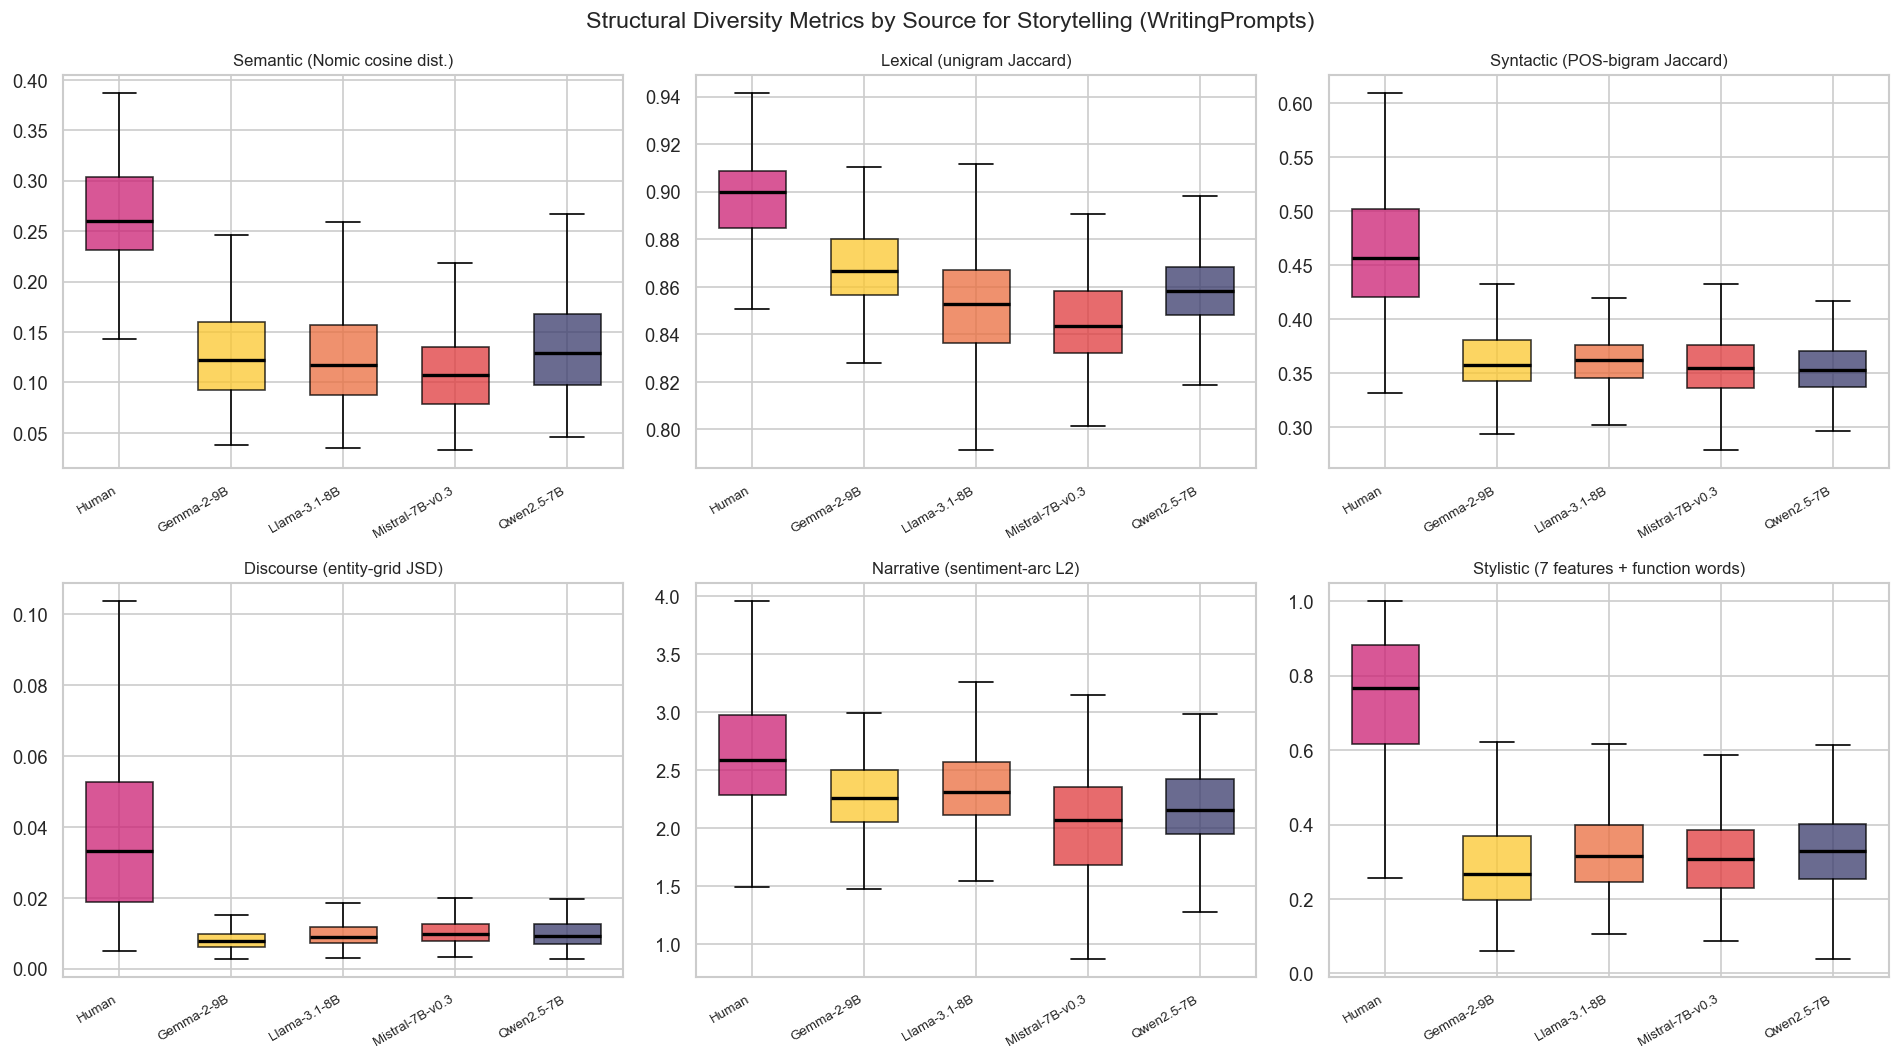

In [95]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, metric in enumerate(GROUP_METRICS):
    ax = axes[i]
    data = [df_metrics.loc[df_metrics.model == m, metric].dropna().values for m in MODEL_ORDER]
    bp = ax.boxplot(data, patch_artist=True, widths=0.6, tick_labels=MODEL_ORDER, showfliers=False,
                     medianprops=dict(color='black', linewidth=2))
    for patch, m in zip(bp['boxes'], MODEL_ORDER):
        patch.set_facecolor(MODEL_COLORS[m])
        patch.set_alpha(0.75)
    ax.set_title(METRIC_LABELS[metric], fontsize=10)
    ax.set_xticklabels(MODEL_ORDER, rotation=30, ha='right', fontsize=8)

fig.suptitle('Structural Diversity Metrics by Source for Storytelling (WritingPrompts)', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / 'diversity_metrics_by_model.png', dpi=150, bbox_inches='tight')
plt.show()

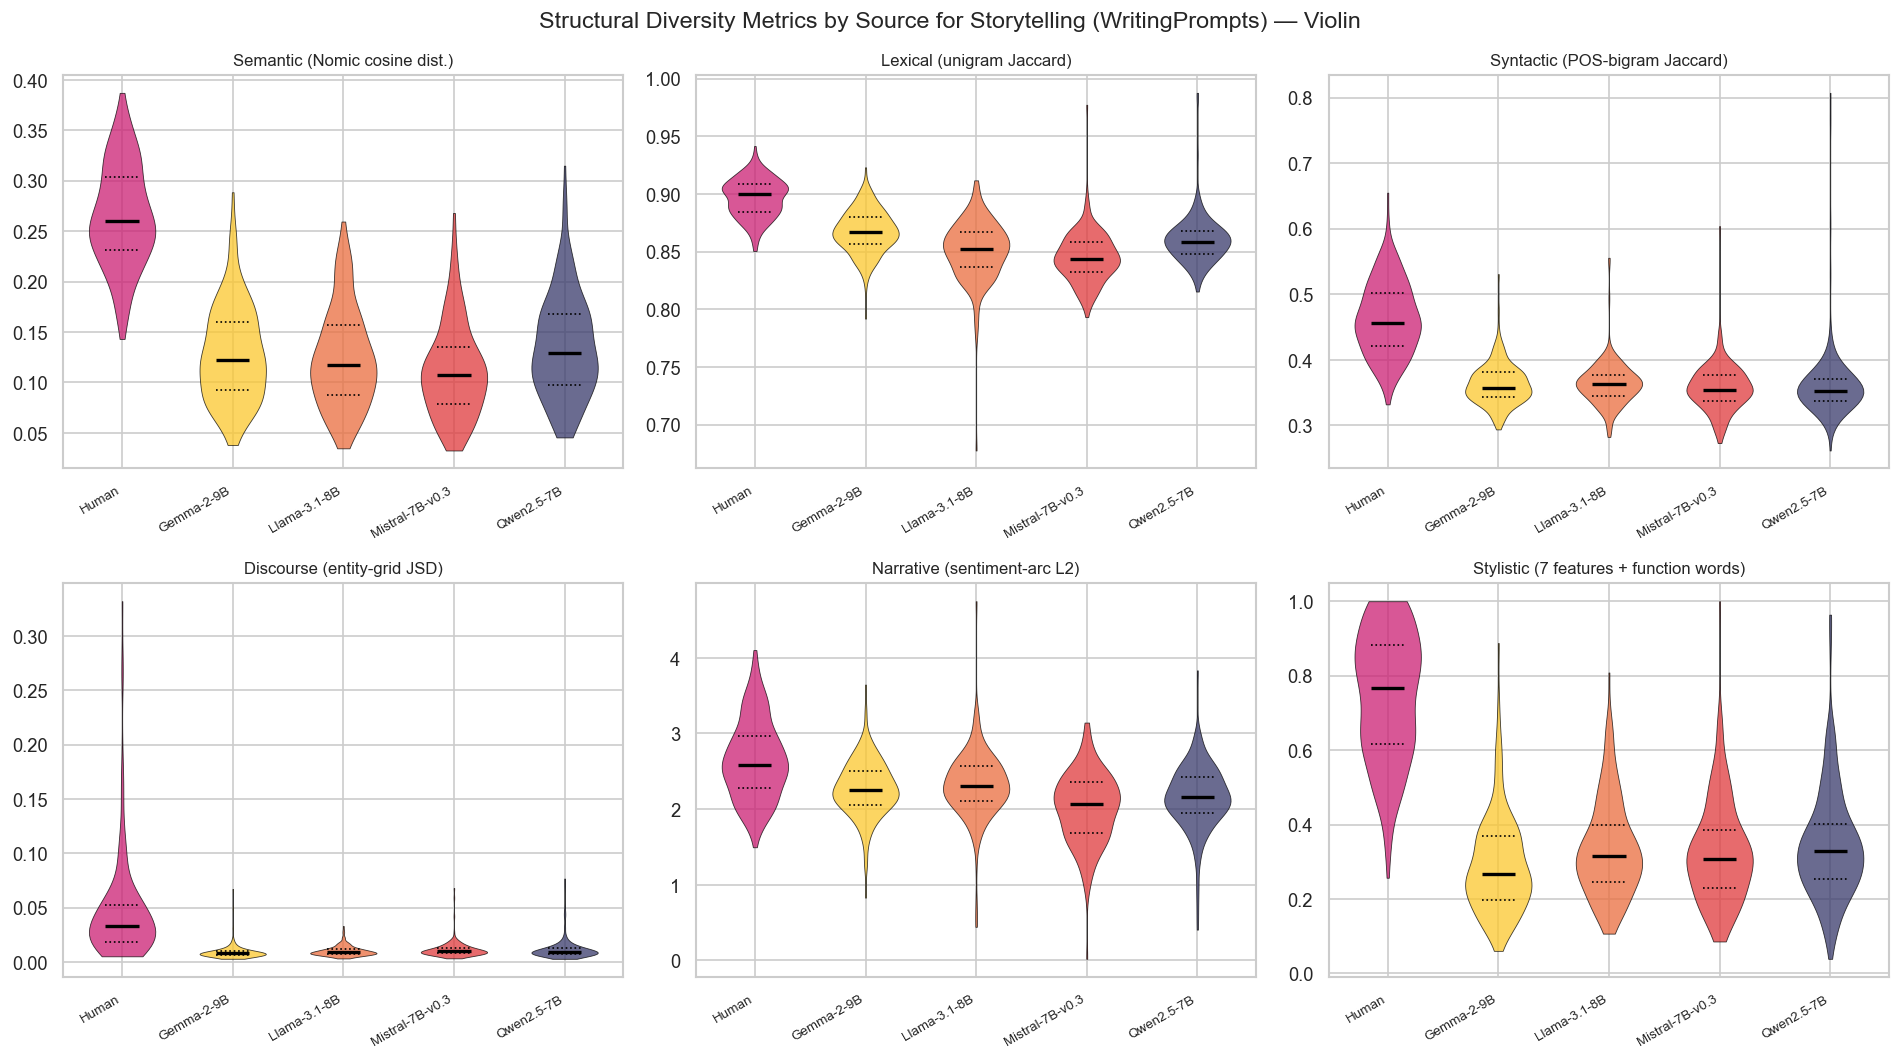

In [96]:
def styled_violin(ax, data, labels, colors, alphas=None):
    """Matplotlib violinplot styled like the paired boxplot above: colored bodies, a solid
    black median line and dotted black Q1/Q3 lines -- shows distribution shape, skew and
    multimodality that a boxplot's five numbers collapse away."""
    alphas = alphas if alphas is not None else [0.75] * len(data)
    positions = range(1, len(data) + 1)
    parts = ax.violinplot(data, positions=positions, widths=0.6, showmedians=True,
                           showextrema=False, quantiles=[[0.25, 0.75]] * len(data))
    for pc, c, a in zip(parts['bodies'], colors, alphas):
        pc.set_facecolor(c)
        pc.set_alpha(a)
        pc.set_edgecolor('black')
        pc.set_linewidth(0.5)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)
    parts['cquantiles'].set_color('black')
    parts['cquantiles'].set_linewidth(1)
    parts['cquantiles'].set_linestyle(':')
    ax.set_xticks(list(positions))
    ax.set_xticklabels(labels)
    return parts


# Violin companion to the boxplot above: same per-prompt group-level values (one point per
# (model, prompt_id), not per individual text) -- shows distribution shape, skew and
# multimodality that the boxplot collapses into five numbers.
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, metric in enumerate(GROUP_METRICS):
    ax = axes[i]
    data = [np.asarray(df_metrics.loc[df_metrics.model == m, metric].dropna().values, dtype=np.float64) for m in MODEL_ORDER]
    styled_violin(ax, data, MODEL_ORDER, [MODEL_COLORS[m] for m in MODEL_ORDER])
    ax.set_title(METRIC_LABELS[metric], fontsize=10)
    ax.set_xticklabels(MODEL_ORDER, rotation=30, ha='right', fontsize=8)

fig.suptitle('Structural Diversity Metrics by Source for Storytelling (WritingPrompts) \u2014 Violin', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / 'diversity_metrics_by_model_violin.png', dpi=150, bbox_inches='tight')
plt.show()

## Metric Intercorrelations

Spearman correlation across the seven metrics, pooling all sources' groups

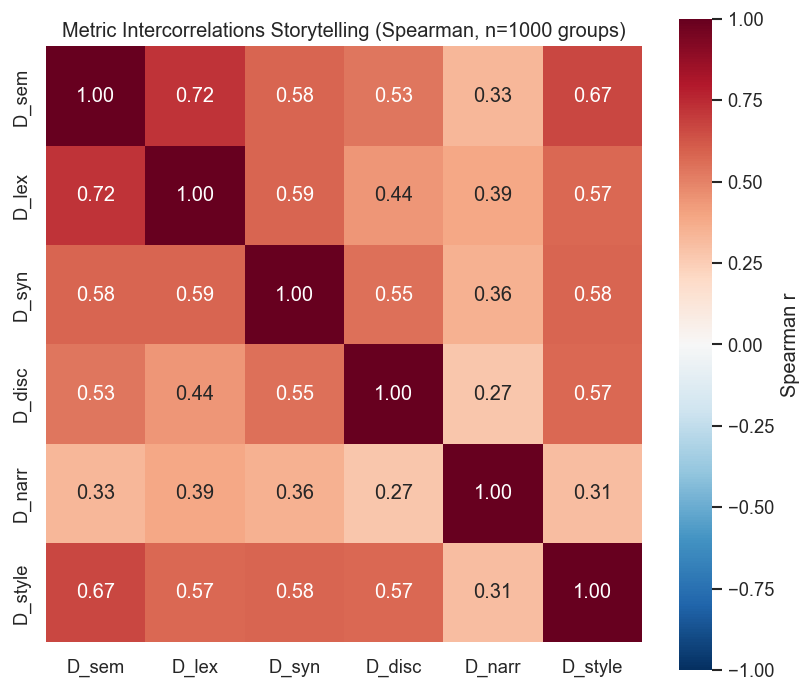

,D_sem,D_lex,D_syn,D_disc,D_narr,D_style
D_sem,1.000,0.725,0.583,0.532,0.331,0.670
D_lex,0.725,1.000,0.585,0.445,0.388,0.571
D_syn,0.583,0.585,1.000,0.553,0.356,0.583
D_disc,0.532,0.445,0.553,1.000,0.274,0.573
D_narr,0.331,0.388,0.356,0.274,1.000,0.308
D_style,0.670,0.571,0.583,0.573,0.308,1.000


In [97]:
corr_cols = GROUP_METRICS
corr_matrix = df_metrics[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
            square=True, cbar_kws={'label': 'Spearman r'}, ax=ax)
ax.set_title('Metric Intercorrelations Storytelling (Spearman, n=%d groups)' % len(df_metrics))
plt.tight_layout()
plt.savefig(FIG_DIR / 'metric_intercorrelations.png', dpi=150, bbox_inches='tight')
plt.show()

corr_matrix.round(3)

## Baseline Metrics Distributions

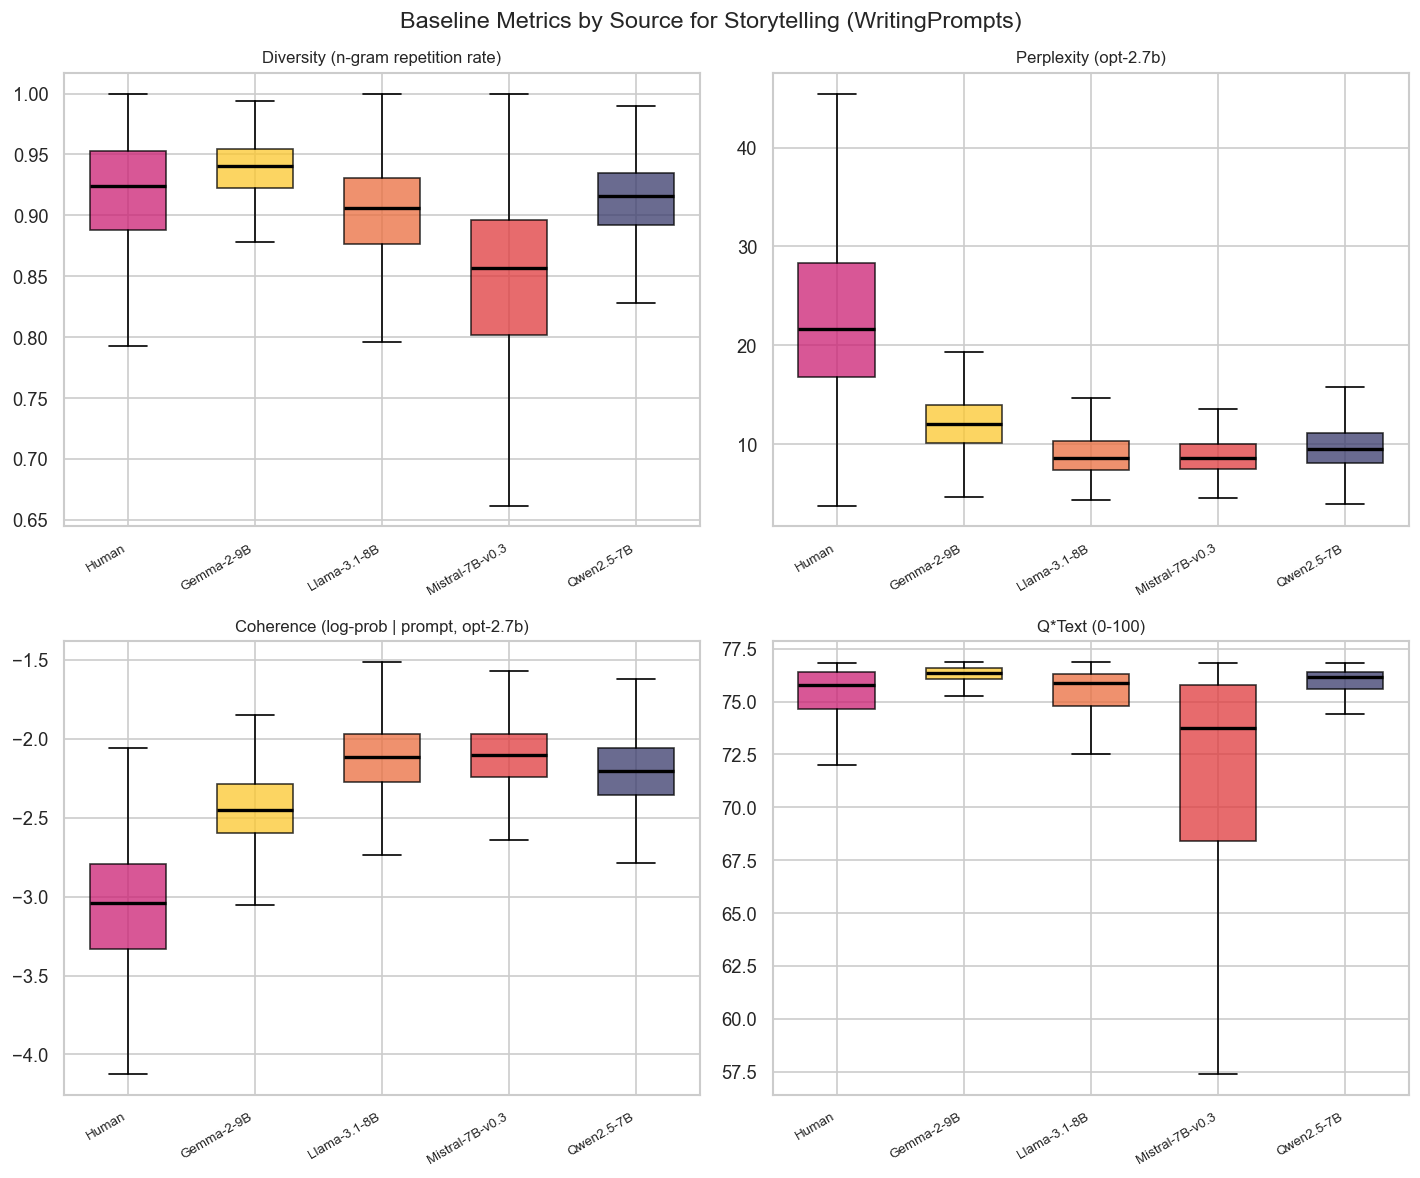

In [98]:
BASELINE_LABELS = {
    'Coherence': f'Coherence (log-prob | prompt, {MODEL_TAG})',
    'Perplexity': f'Perplexity ({MODEL_TAG})',
    'DIV': 'Diversity (n-gram repetition rate)',
    'QStarText': 'Q*Text (0-100)',
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, metric in zip(axes, BASELINE_METRICS):
    data = [df_story.loc[df_story.model == m, metric].dropna().values for m in MODEL_ORDER]
    bp = ax.boxplot(data, patch_artist=True, widths=0.6, tick_labels=MODEL_ORDER, showfliers=False,
                     medianprops=dict(color='black', linewidth=2))
    for patch, m in zip(bp['boxes'], MODEL_ORDER):
        patch.set_facecolor(MODEL_COLORS[m])
        patch.set_alpha(0.75)
    ax.set_title(BASELINE_LABELS[metric], fontsize=10)
    ax.set_xticklabels(MODEL_ORDER, rotation=30, ha='right', fontsize=8)

fig.suptitle('Baseline Metrics by Source for Storytelling (WritingPrompts)', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / 'baseline_metrics_by_model.png', dpi=150, bbox_inches='tight')
plt.show()

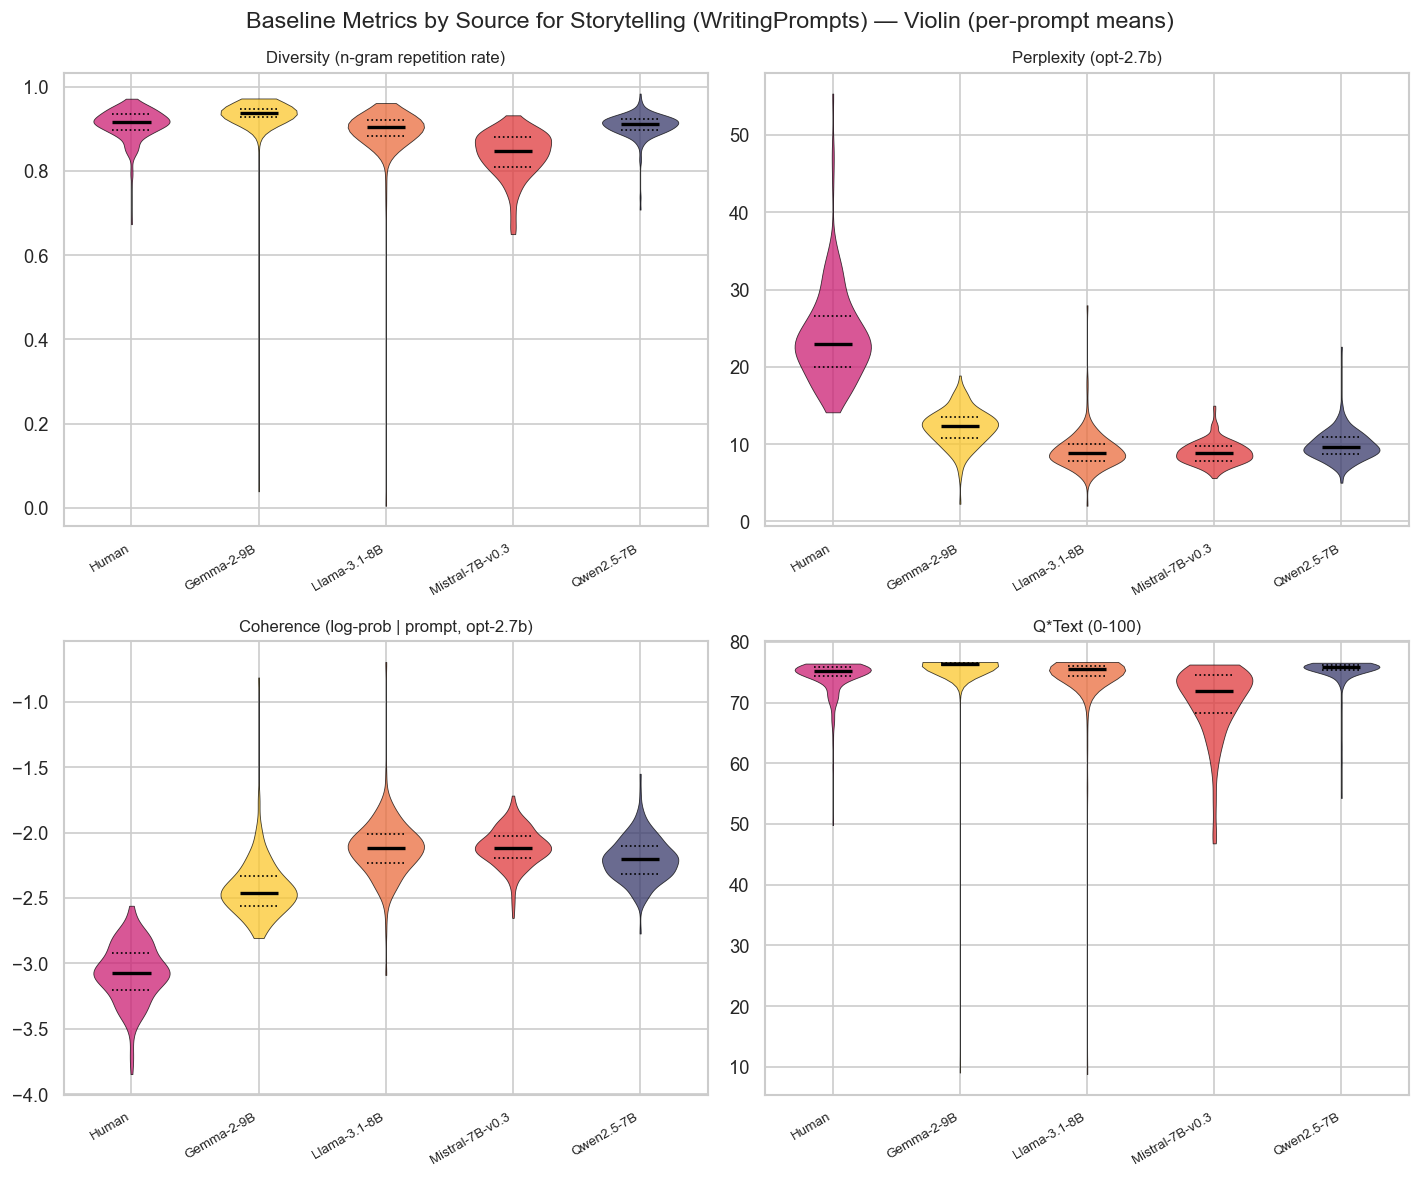

In [99]:
# Violin companion to the boxplot above: aggregated to one value per (model, prompt) -- the
# mean over that prompt's texts -- instead of the per-text values the boxplot uses, so a
# single prompt's five samples don't count as five independent draws.


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, metric in zip(axes, BASELINE_METRICS):
    data = [df_story_prompt.loc[df_story_prompt.model == m, metric].dropna().values for m in MODEL_ORDER]
    styled_violin(ax, data, MODEL_ORDER, [MODEL_COLORS[m] for m in MODEL_ORDER])
    ax.set_title(BASELINE_LABELS[metric], fontsize=10)
    ax.set_xticklabels(MODEL_ORDER, rotation=30, ha='right', fontsize=8)

fig.suptitle('Baseline Metrics by Source for Storytelling (WritingPrompts) \u2014 Violin (per-prompt means)', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / 'baseline_metrics_by_model_violin.png', dpi=150, bbox_inches='tight')
plt.show()

## Export Results

In [100]:
out_path = TABLES_DIR / 'writingprompts_diversity_results.csv'
df_metrics.to_csv(out_path, index=False)
print(f'Exported group-level results: {out_path} ({len(df_metrics)} rows)')

summary_out_path = TABLES_DIR / 'writingprompts_diversity_summary.csv'
summary_table.to_csv(summary_out_path)
print(f'Exported per-model summary: {summary_out_path}')

# Model-tagged: this file's Perplexity/Coherence/QStarText columns are scorer-dependent
df_story.to_csv(CACHE_DIR / f'cache_baseline_metrics_{MODEL_TAG}.csv', index=False)
baseline_summary = df_story.groupby('model')[BASELINE_METRICS].agg(['mean', 'std']).reindex(MODEL_ORDER)
baseline_summary.to_csv(TABLES_DIR / f'writingprompts_baseline_summary_{MODEL_TAG}.csv')
print(f'Exported baseline metrics ({len(df_story)} texts) and per-model summary')

Exported group-level results: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/metrics/06_writingprompts_diversity/tables/writingprompts_diversity_results.csv (1000 rows)
Exported per-model summary: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/metrics/06_writingprompts_diversity/tables/writingprompts_diversity_summary.csv
Exported baseline metrics (4972 texts) and per-model summary


## Human–Model & Human–Human Distances (Matched Reference/Control Split)

So far every group-level metric is a *within-source* distance: the pairwise distances among one source's samples for one prompt    Here: **distance to the human reference** for every source, using a matched design: 
1. Split each prompt's (capped-at-5) human refs into a fixed `H_ref` (`REF_SIZE = 3`) and `H_ctrl` (the other 2)
2. Score **both** control humans and models against that identical `H_ref` —> model and human-control bands are always evaluated against reference sets of the same size
3. Repeats over every possible split (`C(5, 3) = 10`, enumerated exhaustively)
4. Tags each row with `split_id` -> per-split, per-prompt paired difference (model distance-to-reference minus control distance-to-reference, same reference) is available later  

In [101]:
import pickle
from metrics.metrics_lib.pairwise import (
    distance_matrix, within_between, slices_from_lengths, style_distance_matrices)

# Define constants for pairing matrices and reference prompts
PAIRING_DIR = TABLES_DIR
MATRIX_CACHE = CACHE_DIR / f'cache_pairing_matrices_{DATA_FINGERPRINT}.pkl'

# Min human texts for a prompt to enter the human-human / human-model bands
MIN_HUMAN_REF = 5 

# One-call matrix, D_style added after
DIST_METRICS = ['D_sem', 'D_lex', 'D_syn', 'D_disc', 'D_narr']   
PAIRING_METRICS = DIST_METRICS + ['D_style']

SOURCE_ORDER = ['human', 'gemma', 'llama', 'mistral', 'qwen']
MODEL_SOURCES = [s for s in SOURCE_ORDER if s != 'human']

# (model_key, prompt_id) -> list of generation texts
model_texts = {(mk, pid): g['story'].tolist()
               for (mk, pid), g in df_gen.groupby(['model_key', 'prompt_id'])}

# A matrix is built over [humans | model_1 | ...] for EVERY prompt with a human block (>= 2 refs) and >= 1 model 
segments_by_prompt = {}

for pid, hum in human_stories_by_prompt.items():

    if len(hum) < 2:
        continue

    segs = [('human', hum)]
    for mk in MODEL_SOURCES:
        mt = model_texts.get((mk, pid), [])
        if len(mt) >= 2:
            segs.append((mk, mt))

    if len(segs) >= 2:
        segments_by_prompt[pid] = segs

pairing_prompts = sorted(segments_by_prompt)
ref_prompts = [p for p in pairing_prompts if len(segments_by_prompt[p][0][1]) >= MIN_HUMAN_REF]
ref_prompts_set = set(ref_prompts)


print(f'{len(pairing_prompts)} prompts with a usable matrix; '
      f'{len(ref_prompts)} with >= {MIN_HUMAN_REF} human refs (reference/control bands)')
print('human refs per prompt:',
      pd.Series([len(segments_by_prompt[p][0][1]) for p in pairing_prompts])
        .value_counts().sort_index().to_dict())
print('model sources present per prompt:',
      pd.Series([len(segments_by_prompt[p]) - 1 for p in pairing_prompts])
        .value_counts().sort_index().to_dict())

200 prompts with a usable matrix; 199 with >= 5 human refs (reference/control bands)
human refs per prompt: {4: 1, 5: 199}
model sources present per prompt: {4: 200}


In [102]:
# One distance matrix per (metric, prompt) over [humans | model_1 | ...], incrementally cached.
if MATRIX_CACHE.exists():
    with open(MATRIX_CACHE, 'rb') as fh:
        pairing_matrices = pickle.load(fh)
else:
    pairing_matrices = {}

# Count how many (metric, prompt) matrices are still missing from the cache
n_todo = sum((m, p) not in pairing_matrices for m in DIST_METRICS for p in pairing_prompts)
print(f'{n_todo} (metric, prompt) matrices to compute; {len(pairing_matrices)} already cached')


# Compute and cache the distance matrices for each metric and prompt, skipping those already cached
for metric in DIST_METRICS:

    # Identify which prompts still need a distance matrix for this metric
    pending = [p for p in pairing_prompts if (metric, p) not in pairing_matrices]

    if not pending:
        print(f'{metric}: all {len(pairing_prompts)} cached')
        continue

    # Compute the distance matrices for the pending prompts
    t0 = time.time()
    for pid in tqdm(pending, desc=metric):
        texts = [t for _, seg in segments_by_prompt[pid] for t in seg]
        try:
            pairing_matrices[(metric, pid)] = distance_matrix(metric, texts)
        except Exception:
            pairing_matrices[(metric, pid)] = None

    # Checkpoint after every metric
    with open(MATRIX_CACHE, 'wb') as fh:                       
        pickle.dump(pairing_matrices, fh)

    # Count how many matrices were successfully computed and cached for this metric
    ok = sum(1 for p in pairing_prompts if pairing_matrices.get((metric, p)) is not None)

    print(f'{metric}: {ok}/{len(pairing_prompts)} matrices in {time.time() - t0:.0f}s')

# D_style: per-pair components winsorized + min-max normalized across every
# (prompt, humans+models) block at once -> compute in one shot, not per prompt
if all(('D_style', p) in pairing_matrices for p in pairing_prompts):
    print('D_style: all cached')

else:
    t0 = time.time()
    seg_texts = {pid: [t for _, seg in segments_by_prompt[pid] for t in seg] for pid in pairing_prompts}
    for pid, M in style_distance_matrices(seg_texts).items():
        pairing_matrices[('D_style', pid)] = M

    with open(MATRIX_CACHE, 'wb') as fh:
        pickle.dump(pairing_matrices, fh)
        
    print(f'D_style: {len(seg_texts)} matrices in {time.time() - t0:.0f}s')

0 (metric, prompt) matrices to compute; 1200 already cached
D_sem: all 200 cached
D_lex: all 200 cached
D_syn: all 200 cached
D_disc: all 200 cached
D_narr: all 200 cached
D_style: all cached


In [103]:
# within_between() every cached matrix -> long table of individual distances
# 'model-model' = within-source, every pairing_prompt  
# 'human-human' (control)
# 'human-model' (distance to reference) only where the prompt has >= MIN_HUMAN_REF human refs.

rows = []

# Compute the within/between distances for each metric and prompt and store them in a long format DataFrame
for metric in PAIRING_METRICS:
    for pid in pairing_prompts:

        # Get the distance matrix for this (metric, prompt) pair
        M = pairing_matrices.get((metric, pid))
        if M is None:
            continue

        # Get the segments (source, texts) for this prompt
        segs = segments_by_prompt[pid]

        # Compute the within-between distances using the segments and the distance matrix
        wb = within_between(M, slices_from_lengths([(s, len(t)) for s, t in segs]))
        is_ref = pid in ref_prompts_set

        # Add the within-source distances to the rows list, tagging them as 'human-human' or 'model-model'
        for src, arr in wb.within.items():
            if src == 'human':
                if not is_ref:
                    continue
                tag = 'human-human'
            else:
                tag = 'model-model'
            rows.extend((metric, pid, src, tag, float(d)) for d in arr)

        # Add the between-source distances to the rows list, tagging them as 'human-model' only for reference prompts
        if is_ref:
            for src, _ in segs[1:]:
                rows.extend((metric, pid, src, 'human-model', float(d))
                            for d in wb.between.get(('human', src), []))

# Create a long-format DataFrame of the pairing distances and a summary DataFrame with mean, std and count for each metric, source and pairing type
df_pairing_long = pd.DataFrame(rows, columns=['metric', 'prompt_id', 'source', 'pairing', 'dist'])
df_pairing = (df_pairing_long.groupby(['metric', 'source', 'pairing'])['dist']
              .agg(['mean', 'std', 'count']).reset_index())
df_pairing_long.to_csv(PAIRING_DIR / 'pairing_distances_long.csv', index=False)
df_pairing.to_csv(PAIRING_DIR / 'pairing_distances_summary.csv', index=False)

print(f'{len(df_pairing_long):,} individual distances -> pairing_distances_long.csv')

# Sanity check: the 'model-model' within means must match the existing group scores in df_metrics
# (exact for D_sem/D_lex/D_syn/D_narr; D_disc has a small gap: per-pair vs aggregate trigram blend).
_chk = (df_pairing_long[df_pairing_long.pairing == 'model-model']
        .groupby(['metric', 'prompt_id', 'source'])['dist'].mean().rename('matrix_within'))
_ref = (df_metrics.reset_index()[['model_key', 'prompt_id'] + DIST_METRICS]
        .melt(['model_key', 'prompt_id'], var_name='metric', value_name='group_score')
        .rename(columns={'model_key': 'source'}))
_cmp = _ref.merge(_chk, on=['metric', 'prompt_id', 'source'])
_cmp['abs_diff'] = (_cmp.matrix_within - _cmp.group_score).abs()

print('max |matrix within-mean - df_metrics group score| per metric:')
print(_cmp.groupby('metric')['abs_diff'].max().round(6))

df_pairing.pivot_table(index=['metric', 'source'], columns='pairing', values='mean').round(4)

175,750 individual distances -> pairing_distances_long.csv
max |matrix within-mean - df_metrics group score| per metric:
metric
D_disc    0.0
D_lex     0.0
D_narr    0.0
D_sem     0.0
D_syn     0.0
Name: abs_diff, dtype: float64


pairing          human-human  human-model  model-model
metric  source                                        
D_disc  gemma            NaN       0.0318       0.0088
        human         0.0453          NaN          NaN
        llama            NaN       0.0316       0.0101
        mistral          NaN       0.0325       0.0112
        qwen             NaN       0.0323       0.0110
D_lex   gemma            NaN       0.9168       0.8674
        human         0.8965          NaN          NaN
        llama            NaN       0.9082       0.8507
        mistral          NaN       0.9111       0.8448
        qwen             NaN       0.9078       0.8596
D_narr  gemma            NaN       2.6848       2.2747
        human         2.6231          NaN          NaN
        llama            NaN       2.8158       2.3048
        mistral          NaN       3.2153       2.0167
        qwen             NaN       2.9153       2.1379
D_sem   gemma            NaN       0.2462       0.1286
        human         0.2650          NaN          NaN
        llama            NaN       0.2426       0.1241
        mistral          NaN       0.2466       0.1117
        qwen             NaN       0.2510       0.1356
D_style gemma            NaN       0.5738       0.2632
        human         0.5463          NaN          NaN
        llama            NaN       0.5558       0.2870
        mistral          NaN       0.5812       0.2825
        qwen             NaN       0.5666       0.2920
D_syn   gemma            NaN       0.4548       0.3622
        human         0.4630          NaN          NaN
        llama            NaN       0.4501       0.3622
        mistral          NaN       0.4572       0.3570
        qwen             NaN       0.4448       0.3598

In [104]:
from metrics.metrics_lib.pairwise import reference_control_splits

# |H_ref|, H_ctrl = the remaining human refs (2, since ref_prompts have exactly 5)
REF_SIZE = 3

# Split the pairing distances into reference and control bands for each metric and prompt, storing them in a long format DataFrame
rows_split = []
for metric in PAIRING_METRICS:

    # Only compute reference/control splits for prompts with enough human references
    for pid in ref_prompts:
        M = pairing_matrices.get((metric, pid))
        if M is None:
            continue

        # Get the segments (source, texts) for this prompt
        segs = segments_by_prompt[pid]
        n_human = len(segs[0][1])

        # Compute the slices for each source based on the lengths of their text segments
        slices = slices_from_lengths([(s, len(t)) for s, t in segs])
        model_slices = {s: sl for s, sl in slices.items() if s != 'human'}

        # Compute the reference and control splits for this metric, prompt and slices, yielding a dictionary of bands for each split
        for split_id, bands in reference_control_splits(M, n_human, model_slices, REF_SIZE):
            ctrl_arr = bands.pop('human-human')
            rows_split.extend((metric, pid, split_id, 'human', 'human-human', float(d)) for d in ctrl_arr)

            # Add the human-model distances for each model source to the rows_split list
            for src, arr in bands.items():
                rows_split.extend((metric, pid, split_id, src, 'human-model', float(d)) for d in arr)

df_split_long = pd.DataFrame(
    rows_split, columns=['metric', 'prompt_id', 'split_id', 'source', 'pairing', 'dist'])
df_split_long.to_csv(PAIRING_DIR / 'pairing_split_distances_long.csv', index=False)

# Count how many splits per prompt were generated and print a summary
n_splits_per_prompt = sorted(df_split_long.groupby('prompt_id').split_id.nunique().unique())
print(f'{len(df_split_long):,} individual distances, {n_splits_per_prompt} splits/prompt '
      f'-> pairing_split_distances_long.csv')


770,796 individual distances, [np.int64(10)] splits/prompt -> pairing_split_distances_long.csv


### Delta to Human Control

```
delta = mean(dist | human-model) - mean(dist | human-human)
```

- same-reference, same-split comparison
- `delta > 0` means the model sits further from that split's human reference than the held-out control humans do (less human-like on this dimension)
- `delta < 0` means closer.

`C(5, 3) = 10` splits of a prompt are not independent draws (share the same 5-human pool) -> averaged first, then giving one `delta` per `(metric, model, prompt)`    

Prompts are independent -> aggregate below resamples prompts (95% bootstrap CI, percentile method, 10,000 resamples)

In [105]:
# Delta to human reference vs. human control, per (metric, prompt, split), then averaged
# over splits per prompt. 
# Reuses df_split_long from the matched split above (same H_ref within a given split_id for both bands).
ctrl_mean = (df_split_long[df_split_long.pairing == 'human-human']
             .groupby(['metric', 'prompt_id', 'split_id'])['dist'].mean()
             .rename('ctrl_mean'))
model_mean = (df_split_long[df_split_long.pairing == 'human-model']
              .groupby(['metric', 'prompt_id', 'split_id', 'source'])['dist'].mean()
              .rename('model_mean'))

# Merge the model means with the control means on (metric, prompt_id, split_id) to compute the delta for each split
df_delta_split = model_mean.reset_index().merge(
    ctrl_mean.reset_index(), on=['metric', 'prompt_id', 'split_id'], how='inner')
df_delta_split['delta'] = df_delta_split['model_mean'] - df_delta_split['ctrl_mean']

# Average over the (up to C(5,3)=10) splits per prompt -> one delta per (metric, source, prompt)
df_delta_prompt = (df_delta_split.groupby(['metric', 'source', 'prompt_id'])['delta']
                    .mean().reset_index())
df_delta_prompt.to_csv(PAIRING_DIR / 'delta_to_human_control_per_prompt.csv', index=False)

# Sanity check: how many splits per prompt were averaged to produce the final delta
n_splits_check = df_delta_split.groupby(['metric', 'source', 'prompt_id']).size()
print(f'{len(df_delta_prompt)} (metric, model, prompt) deltas -> delta_to_human_control_per_prompt.csv')

print(f'splits averaged per prompt: {sorted(n_splits_check.unique())}')
df_delta_prompt.groupby(['metric', 'source'])['delta'].describe().round(4)

4768 (metric, model, prompt) deltas -> delta_to_human_control_per_prompt.csv
splits averaged per prompt: [np.int64(6), np.int64(9), np.int64(10)]


count    mean     std     min     25%     50%     75%     max
metric  source                                                                
D_disc  gemma    199.0 -0.0143  0.0238 -0.1316 -0.0195 -0.0097 -0.0024  0.1109
        llama    199.0 -0.0137  0.0305 -0.1319 -0.0207 -0.0095 -0.0023  0.2660
        mistral  199.0 -0.0140  0.0250 -0.1387 -0.0215 -0.0098  0.0002  0.0539
        qwen     199.0 -0.0137  0.0253 -0.1319 -0.0200 -0.0092 -0.0007  0.0879
D_lex   gemma    199.0  0.0203  0.0128 -0.0073  0.0113  0.0182  0.0278  0.0896
        llama    199.0  0.0119  0.0154 -0.0239  0.0023  0.0089  0.0180  0.0994
        mistral  199.0  0.0145  0.0147 -0.0156  0.0045  0.0139  0.0220  0.1083
        qwen     199.0  0.0114  0.0150 -0.0148  0.0016  0.0087  0.0185  0.1239
D_narr  gemma    197.0  0.0402  0.4025 -1.0424 -0.2416  0.0052  0.2610  1.2580
        llama    197.0  0.1767  0.4472 -1.0737 -0.1237  0.1245  0.4381  1.3900
        mistral  197.0  0.5626  0.5469 -0.7772  0.1828  0.5477  0.9113  2.1192
        qwen     197.0  0.2710  0.4848 -0.8017 -0.0428  0.2261  0.5750  1.7112
D_sem   gemma    199.0 -0.0188  0.0279 -0.0753 -0.0363 -0.0212 -0.0053  0.1314
        llama    199.0 -0.0217  0.0303 -0.0838 -0.0430 -0.0255 -0.0069  0.1495
        mistral  199.0 -0.0186  0.0268 -0.0776 -0.0369 -0.0223 -0.0052  0.0797
        qwen     199.0 -0.0139  0.0287 -0.0861 -0.0314 -0.0154 -0.0008  0.1128
D_style gemma    199.0  0.0273  0.0933 -0.1388 -0.0404  0.0122  0.0783  0.4240
        llama    199.0  0.0108  0.0897 -0.1382 -0.0511 -0.0026  0.0612  0.3866
        mistral  199.0  0.0343  0.1055 -0.1826 -0.0414  0.0237  0.0934  0.4465
        qwen     199.0  0.0222  0.1043 -0.1792 -0.0512  0.0047  0.0866  0.4319
D_syn   gemma    199.0 -0.0081  0.0393 -0.0887 -0.0350 -0.0122  0.0169  0.1748
        llama    199.0 -0.0121  0.0462 -0.0863 -0.0400 -0.0170  0.0038  0.3173
        mistral  199.0 -0.0060  0.0437 -0.0874 -0.0354 -0.0103  0.0185  0.3056
        qwen     199.0 -0.0178  0.0515 -0.0868 -0.0455 -0.0249  0.0002  0.4197

In [106]:
# Sanity check: how many splits were generated per (metric, source, prompt)
split_counts = (
    df_delta_split
    .groupby(['metric', 'source', 'prompt_id'])
    .size()
    .reset_index(name='n_splits')
)

display(
    split_counts[split_counts.n_splits < 10]
    .sort_values(['metric', 'prompt_id', 'source'])
)

,metric,source,prompt_id,n_splits
35,D_disc,gemma,wp_0035,6
234,D_disc,llama,wp_0035,6
433,D_disc,mistral,wp_0035,6
632,D_disc,qwen,wp_0035,6
1598,D_narr,gemma,wp_0006,9
1795,D_narr,llama,wp_0006,9
1992,D_narr,mistral,wp_0006,9
2189,D_narr,qwen,wp_0006,9
1606,D_narr,gemma,wp_0014,9
1803,D_narr,llama,wp_0014,9


In [107]:
# Bootstrap confidence intervals for the mean delta over prompts, per (metric, source)
N_BOOT = 10_000
BOOT_SEED = 0


def bootstrap_mean_ci(values, n_boot=N_BOOT, ci=0.95, seed=BOOT_SEED):
    """Percentile bootstrap CI for the mean of `values` (resampling prompts with replacement)."""

    # Convert values to a NumPy array of floats
    values = np.asarray(values, dtype=float)

    # Use a random number generator with the specified seed for reproducibility
    rng = np.random.default_rng(seed)

    # Generate bootstrap samples by randomly selecting indices with replacement
    idx = rng.integers(0, len(values), size=(n_boot, len(values)))
    boot_means = values[idx].mean(axis=1)

    # Compute the lower and upper percentiles for the confidence interval
    lo, hi = np.percentile(boot_means, [(1 - ci) / 2 * 100, (1 + ci) / 2 * 100])
    return float(lo), float(hi)


rows = []

# Compute the mean delta and bootstrap confidence intervals for each (metric, source) pair and store the results in a summary DataFrame
for metric in PAIRING_METRICS:
    for mk in MODEL_SOURCES:
        vals = df_delta_prompt.loc[(df_delta_prompt.metric == metric) &
                                   (df_delta_prompt.source == mk), 'delta'].values

        # Skip any (metric, source) pairs with fewer than 3 prompts as bootstrapping is not reliable with very small sample sizes
        if len(vals) < 3:
            continue

        # Compute the bootstrap confidence interval for the mean delta
        ci_lo, ci_hi = bootstrap_mean_ci(vals)
        rows.append({'metric': metric, 'source': mk, 'model': MODEL_LABELS[mk],
                     'n_prompts': len(vals), 'mean': vals.mean(), 'median': float(np.median(vals)),
                     'ci_lo': ci_lo, 'ci_hi': ci_hi})

df_delta_summary = pd.DataFrame(rows)
df_delta_summary.to_csv(PAIRING_DIR / 'delta_to_human_control_summary.csv', index=False)
print(f'Exported {len(df_delta_summary)} (metric, model) rows -> delta_to_human_control_summary.csv')
df_delta_summary.round(4)

Exported 24 (metric, model) rows -> delta_to_human_control_summary.csv


,metric,source,model,n_prompts,mean,median,ci_lo,ci_hi
0,D_sem,gemma,Gemma-2-9B,199,-0.0188,-0.0212,-0.0226,-0.0149
1,D_sem,llama,Llama-3.1-8B,199,-0.0217,-0.0255,-0.0258,-0.0174
2,D_sem,mistral,Mistral-7B-v0.3,199,-0.0186,-0.0223,-0.0223,-0.0148
3,D_sem,qwen,Qwen2.5-7B,199,-0.0139,-0.0154,-0.0179,-0.0099
4,D_lex,gemma,Gemma-2-9B,199,0.0203,0.0182,0.0186,0.0221
5,D_lex,llama,Llama-3.1-8B,199,0.0119,0.0089,0.0099,0.0141
6,D_lex,mistral,Mistral-7B-v0.3,199,0.0145,0.0139,0.0126,0.0166
7,D_lex,qwen,Qwen2.5-7B,199,0.0114,0.0087,0.0094,0.0135
8,D_syn,gemma,Gemma-2-9B,199,-0.0081,-0.0122,-0.0135,-0.0025
9,D_syn,llama,Llama-3.1-8B,199,-0.0121,-0.0170,-0.0180,-0.0054


/var/folders/8p/gf18y7cn497_l5dv5x3gp0q40000gp/T/ipykernel_87731/1261389455.py:24: UserWarning: Glyph 9671 (\N{WHITE DIAMOND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/8p/gf18y7cn497_l5dv5x3gp0q40000gp/T/ipykernel_87731/1261389455.py:25: UserWarning: Glyph 9671 (\N{WHITE DIAMOND}) missing from font(s) Arial.
  plt.savefig(FIG_DIR / 'delta_to_human_control_per_metric.png', dpi=150, bbox_inches='tight')
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9671 (\N{WHITE DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


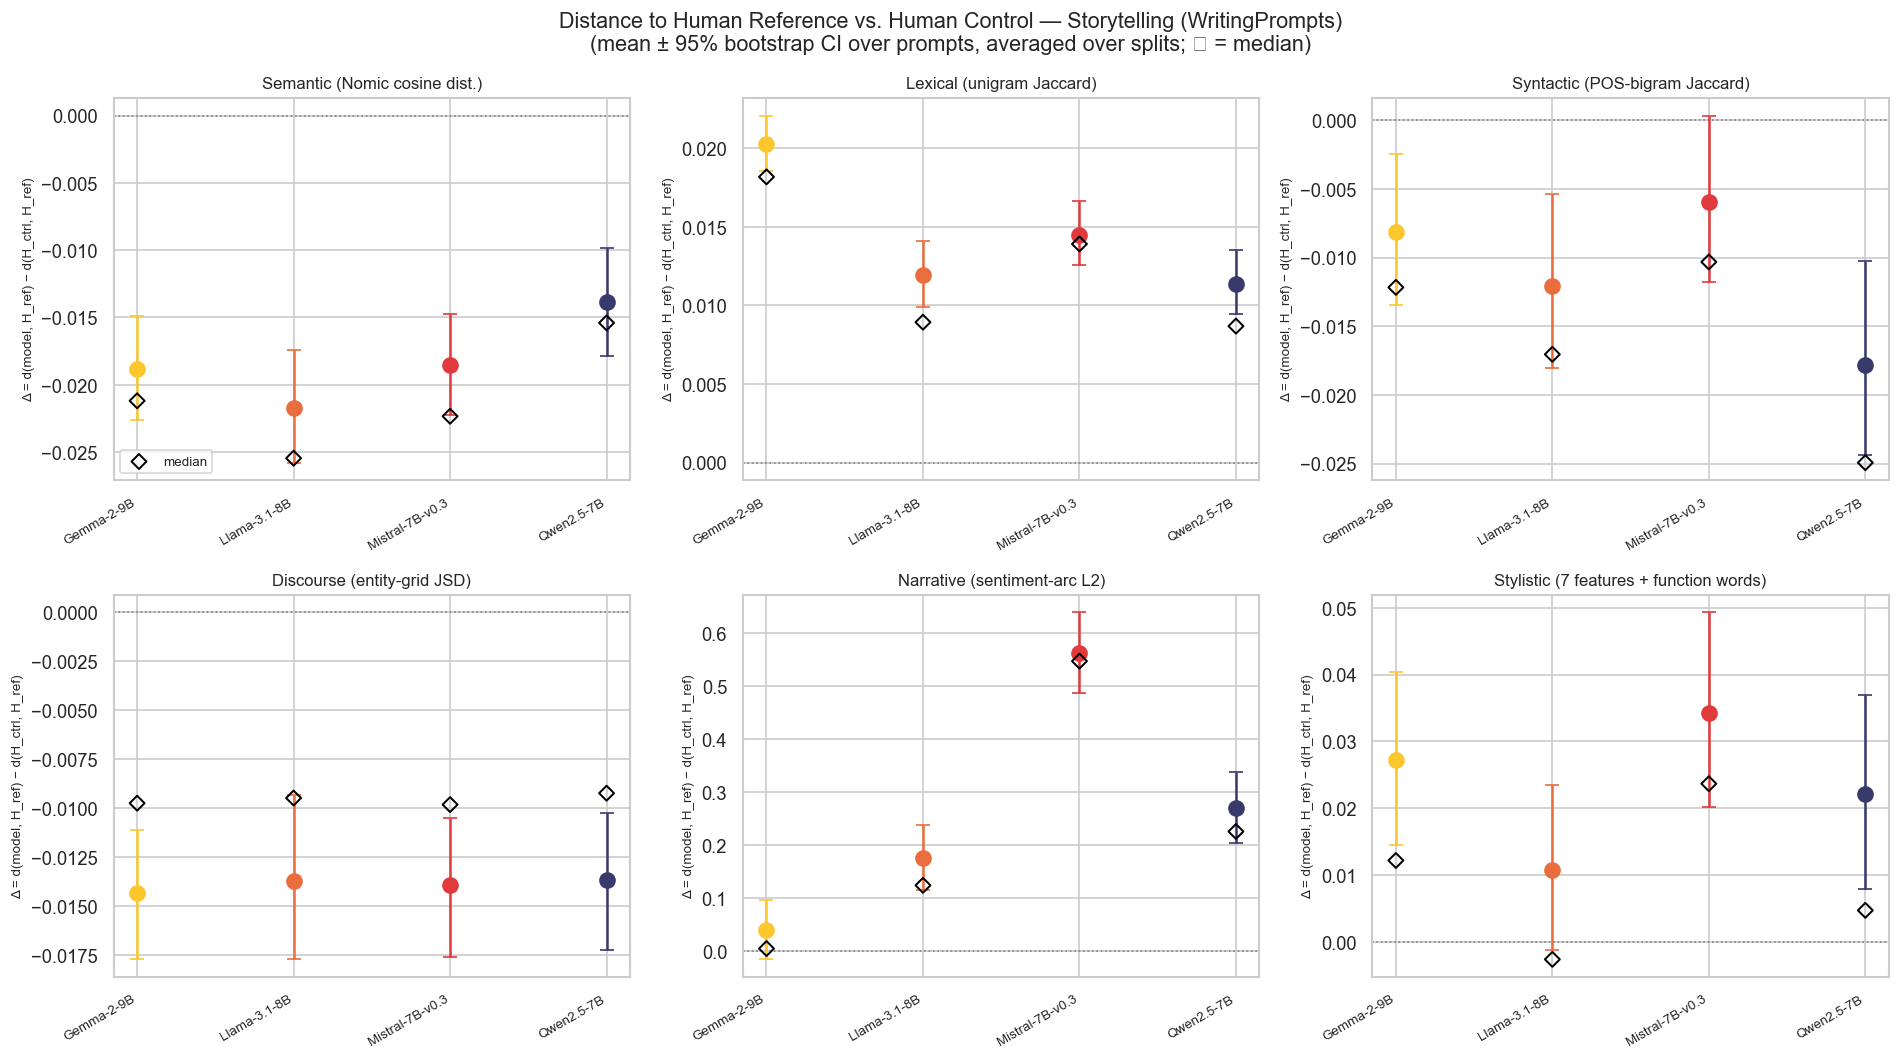

In [108]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, metric in zip(axes, PAIRING_METRICS):
    sub = df_delta_summary[df_delta_summary.metric == metric].set_index('source')
    order = [mk for mk in MODEL_SOURCES if mk in sub.index]
    ax.axhline(0, color='grey', linewidth=1, linestyle=':')
    for xi, mk in enumerate(order):
        row = sub.loc[mk]
        c = MODEL_COLORS[MODEL_LABELS[mk]]
        yerr = [[max(row['mean'] - row['ci_lo'], 0)], [max(row['ci_hi'] - row['mean'], 0)]]
        ax.errorbar(xi, row['mean'], yerr=yerr, fmt='o', color=c, markersize=9,
                    capsize=4, linewidth=1.5, zorder=3)
        ax.scatter(xi, row['median'], marker='D', s=40, facecolors='none', edgecolors='black',
                   linewidth=1.2, zorder=4, label='median' if (ax is axes[0] and xi == 0) else None)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([MODEL_LABELS[mk] for mk in order], rotation=30, ha='right', fontsize=8)
    ax.set_title(METRIC_LABELS[metric], fontsize=10)
    ax.set_ylabel('Δ = d(model, H_ref) − d(H_ctrl, H_ref)', fontsize=8)

axes[0].legend(fontsize=8, loc='best')
fig.suptitle('Distance to Human Reference vs. Human Control — Storytelling (WritingPrompts)\n'
             '(mean ± 95% bootstrap CI over prompts, averaged over splits; ◇ = median)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'delta_to_human_control_per_metric.png', dpi=150, bbox_inches='tight')
plt.show()

In [109]:
# Sensitivity analysis: retain only prompts with all 10 matched reference/control splits available for all four models.

complete_prompts_by_metric = {}

# Count how many prompts have all 10 splits for each metric and model source, and store the complete prompt IDs in a dictionary
for metric in PAIRING_METRICS:
    sub = split_counts[split_counts['metric'] == metric]
    complete = (sub.groupby('prompt_id').apply(
        lambda g:
        set(g['source']) == set(MODEL_SOURCES) and (g['n_splits'] == 10).all()
        )
    )

    # Store the list of complete prompt IDs for this metric in the dictionary
    complete_prompts_by_metric[metric] = complete[complete].index.tolist()
    print(metric, len(complete_prompts_by_metric[metric]), 'complete prompts')
    rows_complete = []

for metric in PAIRING_METRICS:
    prompts = complete_prompts_by_metric[metric]

    # Compute the mean delta and bootstrap confidence intervals for each (metric, source) pair using only the complete prompts
    for mk in MODEL_SOURCES:
        vals = df_delta_prompt.loc[
            (df_delta_prompt['metric'] == metric)
            & (df_delta_prompt['source'] == mk)
            & (df_delta_prompt['prompt_id'].isin(prompts)),
            'delta'
        ].values

        # Skip any (metric, source) pairs with fewer than 3
        if len(vals) < 3:
            continue

        # Compute the bootstrap confidence interval for the mean delta using only the complete prompts
        ci_lo, ci_hi = bootstrap_mean_ci(vals)

        rows_complete.append({
            'metric': metric,
            'source': mk,
            'model': MODEL_LABELS[mk],
            'n_prompts': len(vals),
            'mean': vals.mean(),
            'median': np.median(vals),
            'ci_lo': ci_lo,
            'ci_hi': ci_hi
        })

df_delta_complete = pd.DataFrame(rows_complete)

display(
    df_delta_complete.round(4)
)

D_sem 199 complete prompts
D_lex 199 complete prompts
D_syn 199 complete prompts
D_disc 198 complete prompts
D_narr 190 complete prompts
D_style 199 complete prompts


,metric,source,model,n_prompts,mean,median,ci_lo,ci_hi
0,D_sem,gemma,Gemma-2-9B,199,-0.0188,-0.0212,-0.0226,-0.0149
1,D_sem,llama,Llama-3.1-8B,199,-0.0217,-0.0255,-0.0258,-0.0174
2,D_sem,mistral,Mistral-7B-v0.3,199,-0.0186,-0.0223,-0.0223,-0.0148
3,D_sem,qwen,Qwen2.5-7B,199,-0.0139,-0.0154,-0.0179,-0.0099
4,D_lex,gemma,Gemma-2-9B,199,0.0203,0.0182,0.0186,0.0221
5,D_lex,llama,Llama-3.1-8B,199,0.0119,0.0089,0.0099,0.0141
6,D_lex,mistral,Mistral-7B-v0.3,199,0.0145,0.0139,0.0126,0.0166
7,D_lex,qwen,Qwen2.5-7B,199,0.0114,0.0087,0.0094,0.0135
8,D_syn,gemma,Gemma-2-9B,199,-0.0081,-0.0122,-0.0135,-0.0025
9,D_syn,llama,Llama-3.1-8B,199,-0.0121,-0.0170,-0.0180,-0.0054


### Text-Level Human-Relative Distance Score (`r(t)`)

**Score, `r(t)`.** `r(t) = delta(t) / median(delta(t') for t' in that prompt's human control texts)`.
- Normalizing by the same prompt's human-control median grounds the score in "how far apart humans already are from each other on this prompt"
- `r(t) ~ 1` means a text's distance to that prompt's human reference is human-typical
- `r(t) >> 1` means it lands further from the reference than human variation typically reaches
- A zero human-control median (possible for D_lex/D_syn on short stories) is treated as undefined rather than producing an infinite ratio

`ref_dist_mean` (mean distance to every `H_ref` text) is the primary variant    
`ref_dist_min` (distance to the *nearest* `H_ref` text) as the robustness variant


In [110]:
from metrics.metrics_lib.pairwise import reference_control_splits_rowwise

# delta(t): per-text mean/nearest-neighbor distance to H_ref, averaged over the splits where t is not itself in H_ref 
rows_text = []

for metric in PAIRING_METRICS:
    for pid in ref_prompts:

        # Get the distance matrix for this (metric, prompt) pair
        M = pairing_matrices.get((metric, pid))
        if M is None:
            continue

        # Get the segments (source, texts) for this prompt
        segs = segments_by_prompt[pid]
        n_human = len(segs[0][1])

        # Compute the slices for each source based on the lengths of their text segments
        slices = slices_from_lengths([(s, len(t)) for s, t in segs])
        n = M.shape[0]

        # Initialize arrays to accumulate the sum and count of mean and min distances for each text across splits
        sum_mean = np.zeros(n); cnt_mean = np.zeros(n)
        sum_min = np.zeros(n); cnt_min = np.zeros(n)

        # Compute the reference/control splits for this metric, prompt and slices, yielding a dictionary of bands for each split
        for split_id, ref_idx, row_mean, row_min in reference_control_splits_rowwise(M, n_human, REF_SIZE):
            # Mark the eligible texts for this split (those not in the reference set)
            eligible = np.ones(n, dtype=bool)
            eligible[ref_idx] = False

            # Accumulate the mean and min distances for eligible texts, ensuring they are finite values
            ok = eligible & np.isfinite(row_mean)
            sum_mean[ok] += row_mean[ok]; cnt_mean[ok] += 1
            ok = eligible & np.isfinite(row_min)
            sum_min[ok] += row_min[ok]; cnt_min[ok] += 1

        # Compute the average mean and min distances for each text across all splits, handling cases where no splits were available
        ref_dist_mean = np.where(cnt_mean > 0, sum_mean / np.maximum(cnt_mean, 1), np.nan)
        ref_dist_min = np.where(cnt_min > 0, sum_min / np.maximum(cnt_min, 1), np.nan)

        # Store the per-text deltas in the rows_text list, including only those texts with finite mean distances
        for src, (start, stop) in slices.items():
            for local_idx, row_i in enumerate(range(start, stop)):
                if not np.isfinite(ref_dist_mean[row_i]):
                    continue
                rows_text.append((metric, pid, src, local_idx,
                                  ref_dist_mean[row_i], ref_dist_min[row_i], int(cnt_mean[row_i])))

df_delta_text = pd.DataFrame(rows_text, columns=[
    'metric', 'prompt_id', 'source', 'local_idx', 'ref_dist_mean', 'ref_dist_min', 'n_splits'])
df_delta_text.to_csv(PAIRING_DIR / 'hrd_delta_per_text.csv', index=False)

print(f'{len(df_delta_text):,} per-text deltas -> hrd_delta_per_text.csv')
print('splits averaged per text (human control -> 4 = C(4,3); model -> 10 = C(5,3)):')
print(df_delta_text.groupby(df_delta_text.source.eq('human'))['n_splits'].value_counts().sort_index())

29,575 per-text deltas -> hrd_delta_per_text.csv
splits averaged per text (human control -> 4 = C(4,3); model -> 10 = C(5,3)):
source  n_splits
False   6              39
        9              38
        10          23612
True    3               4
        4            5882
Name: count, dtype: int64


In [111]:
# r(t) = delta(t) / median(delta | human control, same metric+prompt).
ctrl = df_delta_text[df_delta_text.source == 'human']
ctrl_median = (ctrl.groupby(['metric', 'prompt_id'])[['ref_dist_mean', 'ref_dist_min']]
               .median()
               .rename(columns={'ref_dist_mean': 'ctrl_median_mean', 'ref_dist_min': 'ctrl_median_min'}))

# Count how many human-control medians are zero and replace them with NaN to avoid division by zero when computing r(t).
n_zero_mean = int((ctrl_median['ctrl_median_mean'] == 0).sum())
n_zero_min = int((ctrl_median['ctrl_median_min'] == 0).sum())
ctrl_median.loc[ctrl_median['ctrl_median_mean'] == 0, 'ctrl_median_mean'] = np.nan
ctrl_median.loc[ctrl_median['ctrl_median_min'] == 0, 'ctrl_median_min'] = np.nan

df_score_text = df_delta_text.merge(ctrl_median, on=['metric', 'prompt_id'], how='left')
df_score_text['r_mean'] = df_score_text['ref_dist_mean'] / df_score_text['ctrl_median_mean']
df_score_text['r_min'] = df_score_text['ref_dist_min'] / df_score_text['ctrl_median_min']
df_score_text.to_csv(PAIRING_DIR / 'hrd_score_per_text.csv', index=False)

print(f'{len(df_score_text):,} per-text human-relative distance scores -> hrd_score_per_text.csv')
print(f'(metric, prompt) pairs with a zero human-control median, set to NaN instead of inf: '
      f'{n_zero_mean} (mean), {n_zero_min} (min)')
df_score_text.groupby(['metric', 'source'])[['r_mean', 'r_min']].describe().round(3)


29,575 per-text human-relative distance scores -> hrd_score_per_text.csv
(metric, prompt) pairs with a zero human-control median, set to NaN instead of inf: 0 (mean), 0 (min)


r_mean                                                   \
                 count   mean    std    min    25%    50%    75%    max   
metric  source                                                            
D_disc  gemma    995.0  0.908  0.497  0.466  0.672  0.789  0.954  6.717   
        human    969.0  1.139  0.463  0.543  0.883  1.000  1.197  3.664   
        llama    987.0  0.943  0.588  0.382  0.643  0.782  0.986  5.787   
        mistral  980.0  1.051  0.799  0.391  0.654  0.789  1.100  7.996   
        qwen     983.0  0.982  0.620  0.411  0.659  0.777  1.027  5.258   
D_lex   gemma    995.0  1.024  0.017  0.986  1.013  1.022  1.034  1.130   
        human    995.0  1.002  0.011  0.963  0.996  1.000  1.007  1.058   
        llama    991.0  1.015  0.020  0.965  1.003  1.012  1.023  1.134   
        mistral  980.0  1.018  0.019  0.975  1.005  1.017  1.028  1.149   
        qwen     987.0  1.014  0.019  0.974  1.002  1.011  1.023  1.149   
D_narr  gemma    985.0  1.049  0.215  0.622  0.897  1.014  1.149  1.941   
        human    939.0  1.014  0.134  0.720  0.938  1.000  1.067  1.670   
        llama    977.0  1.102  0.226  0.654  0.943  1.062  1.235  1.916   
        mistral  970.0  1.267  0.294  0.664  1.048  1.214  1.439  2.538   
        qwen     971.0  1.145  0.260  0.712  0.952  1.094  1.286  2.113   
D_sem   gemma    995.0  0.947  0.145  0.672  0.859  0.920  1.010  2.181   
        human    995.0  1.015  0.098  0.761  0.961  1.000  1.059  1.451   
        llama    991.0  0.930  0.140  0.662  0.836  0.910  0.997  1.769   
        mistral  980.0  0.946  0.134  0.706  0.852  0.927  1.013  1.966   
        qwen     987.0  0.965  0.142  0.676  0.871  0.946  1.030  1.951   
D_style gemma    995.0  1.103  0.237  0.653  0.931  1.053  1.230  2.314   
        human    993.0  1.025  0.155  0.682  0.940  1.000  1.082  1.908   
        llama    987.0  1.064  0.228  0.651  0.901  1.011  1.172  2.531   
        mistral  980.0  1.116  0.267  0.621  0.931  1.060  1.239  2.528   
        qwen     981.0  1.093  0.268  0.621  0.899  1.024  1.212  2.361   
D_syn   gemma    995.0  1.007  0.100  0.797  0.936  0.993  1.062  1.481   
        human    995.0  1.017  0.078  0.856  0.974  1.000  1.041  1.421   
        llama    991.0  0.996  0.112  0.804  0.928  0.977  1.043  1.975   
        mistral  980.0  1.012  0.109  0.804  0.935  0.993  1.063  1.729   
        qwen     987.0  0.983  0.118  0.800  0.912  0.960  1.026  1.946   

                 r_min                                                    
                 count   mean    std    min    25%    50%    75%     max  
metric  source                                                            
D_disc  gemma    995.0  1.016  0.871  0.226  0.537  0.752  1.134   8.929  
        human    969.0  1.758  3.026  0.304  0.794  1.000  1.378  47.987  
        llama    987.0  1.153  1.088  0.217  0.555  0.799  1.260  10.146  
        mistral  980.0  1.404  1.440  0.256  0.577  0.884  1.602  13.950  
        qwen     983.0  1.214  1.172  0.220  0.538  0.804  1.364   9.071  
D_lex   gemma    995.0  1.030  0.020  0.980  1.016  1.028  1.042   1.137  
        human    995.0  1.002  0.016  0.937  0.994  1.000  1.008   1.094  
        llama    991.0  1.019  0.024  0.949  1.004  1.016  1.030   1.171  
        mistral  980.0  1.022  0.022  0.959  1.007  1.021  1.035   1.161  
        qwen     987.0  1.018  0.022  0.953  1.004  1.016  1.030   1.161  
D_narr  gemma    985.0  1.088  0.289  0.498  0.885  1.037  1.232   2.356  
        human    939.0  1.045  0.222  0.513  0.918  1.000  1.112   2.292  
        llama    977.0  1.157  0.320  0.578  0.920  1.107  1.336   2.507  
        mistral  970.0  1.352  0.410  0.417  1.048  1.269  1.619   3.415  
        qwen     971.0  1.205  0.351  0.591  0.944  1.138  1.392   2.547  
D_sem   gemma    995.0  0.938  0.217  0.537  0.813  0.909  1.023   3.000  
        human    995.0  1.029  0.161  0.533  0.943  1.000  1.082   1.875  
        llama    991.0  0.919  0.215  0.

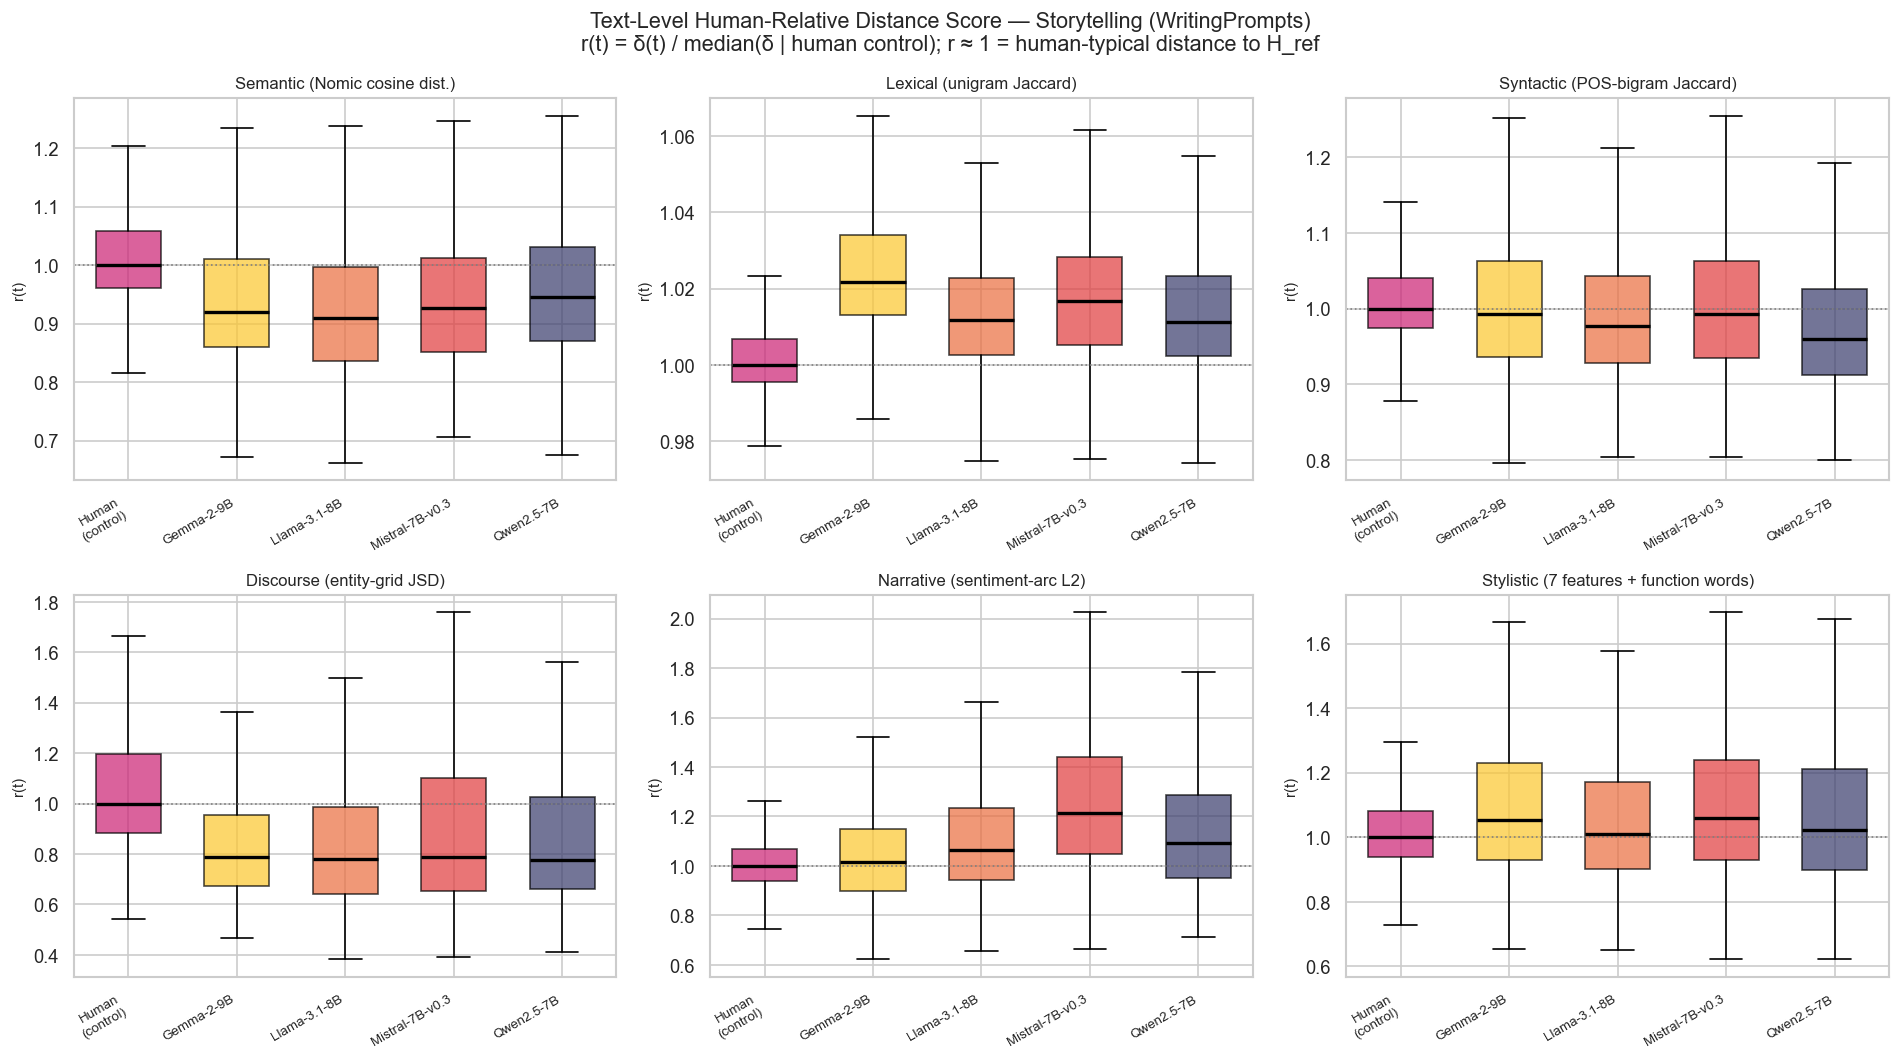

In [112]:
# Distribution of r_mean(t) per metric/source. Human (control) should center near 1 by construction
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, metric in zip(axes, PAIRING_METRICS):
    sub = df_score_text[df_score_text.metric == metric]
    box_data, labels, colors = [], [], []
    box_data.append(sub.loc[sub.source == 'human', 'r_mean'].dropna().values)
    labels.append('Human\n(control)')
    colors.append(MODEL_COLORS['Human'])
    for mk in MODEL_SOURCES:
        box_data.append(sub.loc[sub.source == mk, 'r_mean'].dropna().values)
        labels.append(MODEL_LABELS[mk])
        colors.append(MODEL_COLORS[MODEL_LABELS[mk]])

    bp = ax.boxplot(box_data, patch_artist=True, showfliers=False, widths=0.6,
                    medianprops=dict(color='black', linewidth=2))
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.axhline(1.0, color='grey', linewidth=1, linestyle=':')
    ax.set_title(METRIC_LABELS[metric], fontsize=10)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('r(t)', fontsize=9)

fig.suptitle('Text-Level Human-Relative Distance Score — Storytelling (WritingPrompts)\n'
             'r(t) = δ(t) / median(δ | human control); r ≈ 1 = human-typical distance to H_ref',
             fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'hrd_score_per_text.png', dpi=150, bbox_inches='tight')
plt.show()

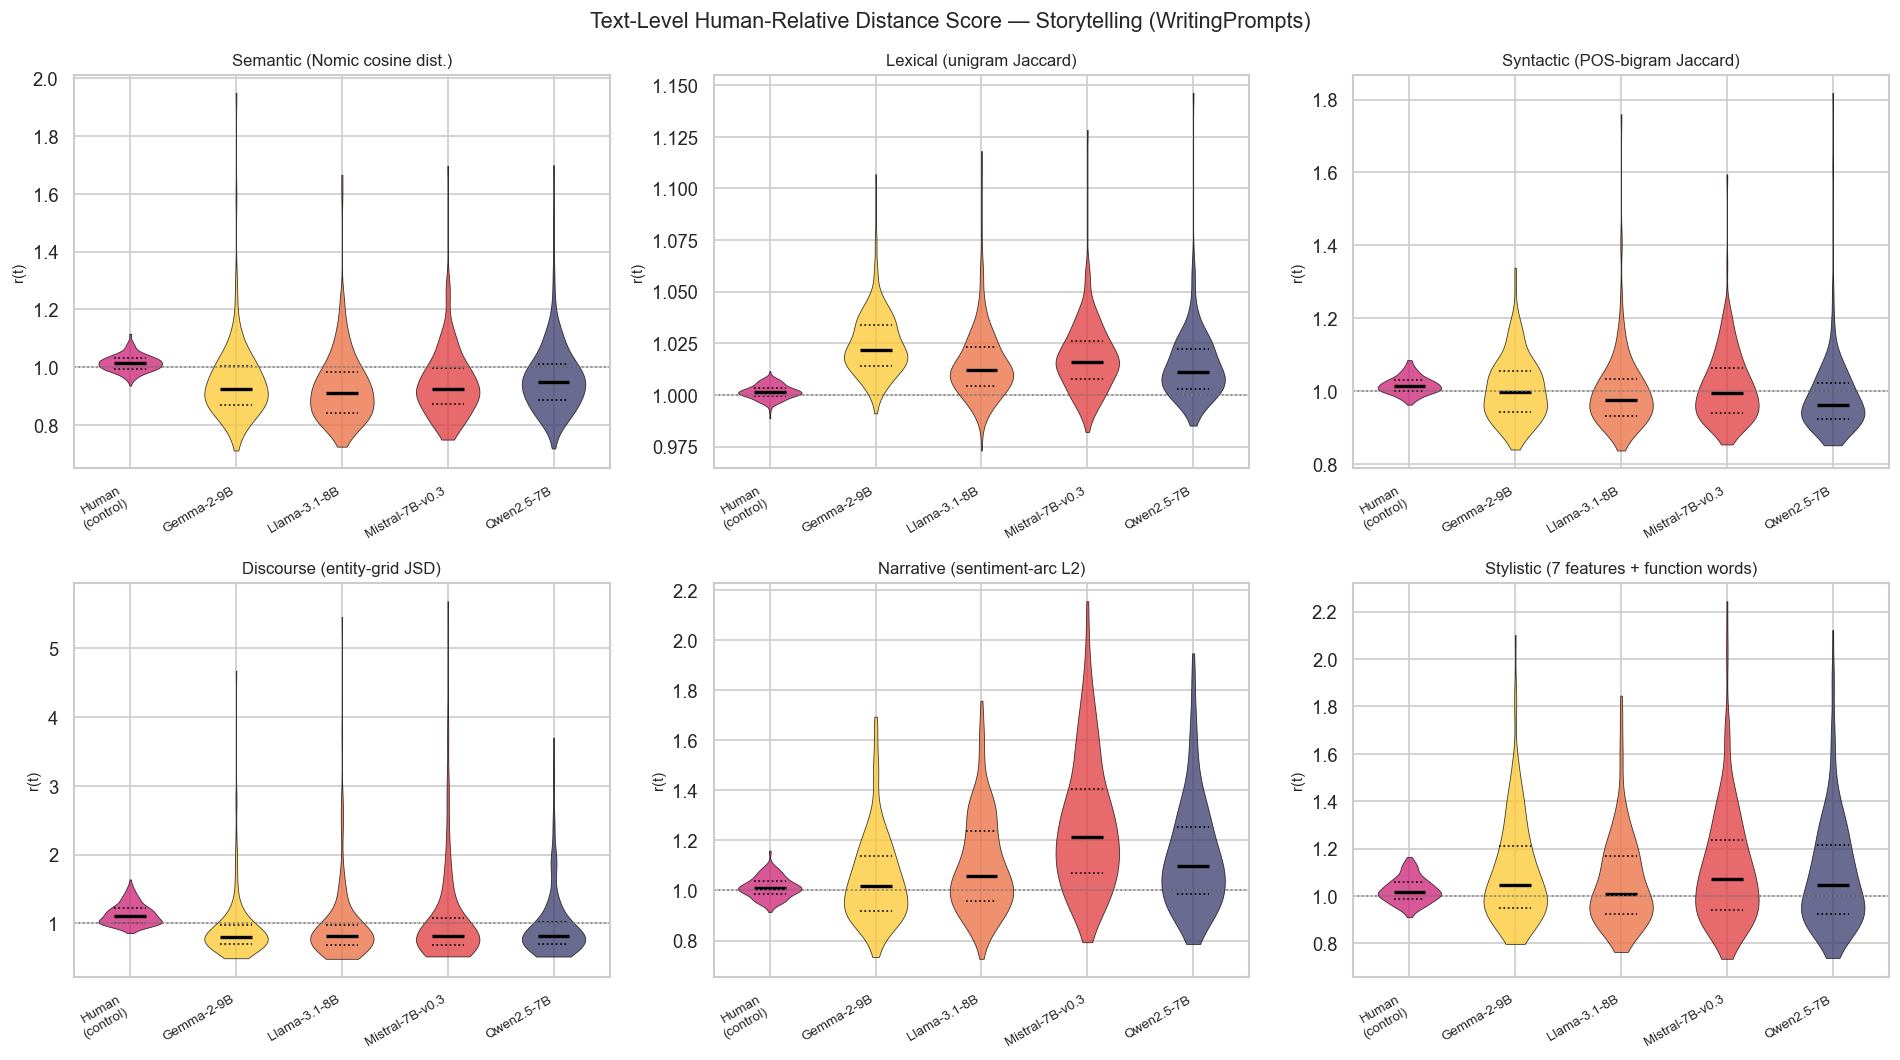

In [113]:
# Violin companion to the boxplot above: mean r(t) per (metric, source, prompt): one point per prompt
df_score_prompt = (df_score_text.groupby(['metric', 'source', 'prompt_id'])['r_mean']
                    .mean().reset_index())

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, metric in zip(axes, PAIRING_METRICS):
    sub = df_score_prompt[df_score_prompt.metric == metric]
    data, labels, colors = [], [], []
    data.append(sub.loc[sub.source == 'human', 'r_mean'].dropna().values)
    labels.append('Human\n(control)')
    colors.append(MODEL_COLORS['Human'])
    for mk in MODEL_SOURCES:
        data.append(sub.loc[sub.source == mk, 'r_mean'].dropna().values)
        labels.append(MODEL_LABELS[mk])
        colors.append(MODEL_COLORS[MODEL_LABELS[mk]])

    styled_violin(ax, data, labels, colors)
    ax.axhline(1.0, color='grey', linewidth=1, linestyle=':')
    ax.set_title(METRIC_LABELS[metric], fontsize=10)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('r(t)', fontsize=9)

fig.suptitle('Text-Level Human-Relative Distance Score \u2014 Storytelling (WritingPrompts)',
             fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'hrd_score_per_text_violin.png', dpi=150, bbox_inches='tight')
plt.show()

## Energy Distance

$$E(H, M) = 2\,\overline{d(H, M)} - \overline{d(H, H')} - \overline{d(M, M')}$$

- The within-group means (`d(H, H')`, `d(M, M')`) are taken over the full `n^2` pairs
- Computed separately per `(metric, prompt, model)`, restricted to `ref_prompts`
- **NaN handling:**: a text with no defined representation for a metric is dropped from its group first
- **Eligible prompts:** per `(metric, model)`, every prompt with a finite `energy_dist` value -- no longer restricted to the intersection across all four models
- **Uncertainty:** 95% bootstrap CI over eligible prompts (input-level bootstrap, percentile method, 10,000 resamples)
- **Prompt-wise permutation test (diagnostic):** for each `(metric, prompt, model)`, a permutation test on that prompt's own pooled distance matrix -- Human/Model group labels are randomly reassigned (exact enumeration of all label splits at these group sizes, Monte Carlo fallback otherwise) and `energy_dist` recomputed each time, giving a one-sided p-value against `H0: no distributional difference for this prompt`
- **Inferential p-value (primary, per model x dimension):** one p-value per `(metric, model)`, from a Monte Carlo permutation test (9,999 draws) on the mean `energy_dist` reported above -- Human/Model labels are reshuffled independently within every eligible prompt's own pool each draw and the per-prompt values re-averaged, giving a null distribution for the mean; one-sided p-value against `H0: no difference in the mean`. Benjamini-Hochberg FDR correction is applied across the 6 metrics x 4 models family (`p_group`, `p_group_fdr`, `sig_fdr_05` in `energy_distance_summary.csv`)
- **Interpretation depends on the underlying distance!**


In [114]:
# Energy distance E(H, M) = 2*mean(d_HM) - mean(d_HH) - mean(d_MM), computed directly from the
# (metric, prompt) distance matrices in `pairing_matrices`
# Within-group means run over the full n**2 pairs

def _energy_stat(D, idx_h, idx_m):
    """D restricted to two disjoint index arrays, assumes every remaining pair is finite."""

    # Compute the cross-group distances between the human and model indices in the distance matrix D
    cross = D[np.ix_(idx_h, idx_m)]
    d_hm = cross[np.isfinite(cross)].mean()

    # Define a nested function to compute the within-group mean distance for a given set of indices
    def within_mean(idx):
        k = len(idx)
        block = D[np.ix_(idx, idx)]
        vals = block[np.triu_indices(k, k=1)]
        vals = vals[np.isfinite(vals)]
        return (2 * vals.sum()) / (k * k)

    # Compute the energy distance using the formula
    return 2 * d_hm - within_mean(idx_h) - within_mean(idx_m)


def energy_distance_hm(D, idx_h, idx_m):
    """Drops texts with no defined distance to anything (all-nan row) from both groups, then
    verifies every remaining pair is actually finite.

    Returns (energy_dist, valid_idx_h, valid_idx_m); (nan, ..., ...) if a group has < 2 valid
    texts left. Raises ValueError if a defined-but-partial nan remains after filtering.
    """

    # Create a copy of the distance matrix D and fill its diagonal with NaN values to ignore self-distances
    D_check = D.copy()
    np.fill_diagonal(D_check, np.nan)
    valid = np.isfinite(D_check).any(axis=1)

    # Create arrays of valid indices for the human and model groups by filtering out any indices that correspond to invalid texts
    idx_h_v = np.asarray([i for i in idx_h if valid[i]])
    idx_m_v = np.asarray([i for i in idx_m if valid[i]])

    # If either group has fewer than 2 valid texts left, return NaN for the energy distance and the valid indices
    if len(idx_h_v) < 2 or len(idx_m_v) < 2:
        return np.nan, idx_h_v, idx_m_v

    # Create a pooled array of valid indices from both groups and extract the corresponding block from the distance matrix D
    pool = np.concatenate([idx_h_v, idx_m_v])
    block = D[np.ix_(pool, pool)].copy()
    np.fill_diagonal(block, 0.0)

    # Check if all values in the block are finite. If not, raise a ValueError
    if not np.isfinite(block).all():
        raise ValueError("Partial NaNs remain after removing invalid texts.")

    # Compute and return the energy statistic using the valid indices for the human and model groups
    return _energy_stat(D, idx_h_v, idx_m_v), idx_h_v, idx_m_v


print('Energy-distance helpers defined: _energy_stat, energy_distance_hm')


Energy-distance helpers defined: _energy_stat, energy_distance_hm


In [115]:
from itertools import combinations
from math import comb

def energy_permutation_test(D, idx_h_v, idx_m_v, exact_limit=20_000, n_perm=9_999, seed=0):
    """Prompt-wise permutation test for E(H, M), built on the same pooled distance block
    as `energy_distance_hm` (already-valid, NaN-filtered index arrays).

    H0: the Human/Model group labels are exchangeable within this prompt's pool. Every
    one of the C(n, n_h) possible label splits is enumerated when that count is
    <= `exact_limit` for an exact p-value (always true at the group sizes seen here,
    pool size <= ~10); otherwise falls back to a fixed-seed Monte Carlo permutation test
    with `n_perm` draws.

    Returns (p_perm, n_splits_used, exact) -- one-sided p-value for E_perm >= E_obs.
    """

    # Compute the number of valid human and model indices, create a pooled array of indices and extract the 
    # corresponding block from the distance matrix D
    n_h, n_m = len(idx_h_v), len(idx_m_v)
    pool = np.concatenate([idx_h_v, idx_m_v])
    block = D[np.ix_(pool, pool)].copy()
    np.fill_diagonal(block, 0.0)

    # Compute the observed energy statistic for the original human and model indices
    n = n_h + n_m
    pos = np.arange(n)
    e_obs = _energy_stat(block, pos[:n_h], pos[n_h:])
    n_exact = comb(n, n_h)

    # If the number of exact permutations is less than or equal to the exact limit, enumerate all combinations of 
    # human indices and compute the energy statistic for each permutation. Count how many permutations have an energy statistic 
    # greater than or equal to the observed energy statistic and return the exact p-value.
    if n_exact <= exact_limit:
        ge = 0
        for combo in combinations(range(n), n_h):

            # Create a boolean mask to identify the indices of the model group based on the current combination of human indices
            idx_h_p = np.array(combo)
            mask = np.ones(n, dtype=bool)
            mask[idx_h_p] = False
            idx_m_p = pos[mask]

            # Compute the energy statistic for the current permutation and check if it is greater than or 
            # equal to the observed energy statistic
            if _energy_stat(block, idx_h_p, idx_m_p) >= e_obs - 1e-9:
                ge += 1

        # Return the exact p-value, the number of exact permutations and a boolean indicating that the result is exact
        return ge / n_exact, n_exact, True

    # Otherwise, perform a Monte Carlo permutation test by randomly permuting the pooled indices and splitting them 
    # into human and model indices
    rng = np.random.default_rng(seed)
    ge = 0
    for _ in range(n_perm):
        # Randomly permute the pooled indices and split them into human and model indices
        perm = rng.permutation(pos)

        # Split the permuted indices into human and model indices based on the number of valid human indices
        idx_h_p, idx_m_p = perm[:n_h], perm[n_h:]

        # Compute the energy statistic for the current permutation and check if it is greater than or equal 
        # to the observed energy statistic
        if _energy_stat(block, idx_h_p, idx_m_p) >= e_obs - 1e-9:
            ge += 1

    # Return the approximate p-value, the number of permutations and a boolean indicating that the result is not exact
    return (ge + 1) / (n_perm + 1), n_perm, False


print('Permutation-test helper defined: energy_permutation_test')


Permutation-test helper defined: energy_permutation_test


In [116]:
rows_energy = []
n_partial_nan = 0
 # (metric, prompt_id, source) -> (pooled_block, n_h_eff)


# Compute the energy distances and permutation test p-values for each metric, prompt ID and model source
energy_valid_blocks = {} 
# Compute the energy distances for each metric, prompt ID and model source
for metric in PAIRING_METRICS:
    for pid in ref_prompts:

        # Retrieve the pairing distance matrix for the current metric and prompt ID from the pairing_matrices dictionary
        M = pairing_matrices.get((metric, pid))
        if M is None:
            continue

        # Retrieve the segments for the current prompt ID from the segments_by_prompt dictionary and
        # compute the slices for the human and model groups
        segs = segments_by_prompt[pid]
        slices = slices_from_lengths([(s, len(t)) for s, t in segs])
        idx_h = np.arange(*slices['human'])

        # For each model source in the segments, compute the energy distance between the human and model groups
        for src, _ in segs[1:]:
            idx_m = np.arange(*slices[src])
            try:
                e_obs, idx_h_v, idx_m_v = energy_distance_hm(M, idx_h, idx_m)

            except ValueError:
                e_obs, idx_h_v, idx_m_v = np.nan, np.array([], dtype=int), np.array([], dtype=int)
                n_partial_nan += 1

            # Prompt-wise permutation test: exact label-split enumeration at these
            # group sizes, Monte Carlo fallback for larger pools
            if np.isfinite(e_obs):
                p_perm, n_perm_used, perm_exact = energy_permutation_test(M, idx_h_v, idx_m_v)
                pool = np.concatenate([idx_h_v, idx_m_v])
                block = M[np.ix_(pool, pool)].copy()
                np.fill_diagonal(block, 0.0)
                energy_valid_blocks[(metric, pid, src)] = (block, len(idx_h_v))
            else:
                p_perm, n_perm_used, perm_exact = np.nan, 0, False

            rows_energy.append({'metric': metric, 'prompt_id': pid, 'source': src, 'energy_dist': e_obs,
                                 'n_human_eff': len(idx_h_v), 'n_model_eff': len(idx_m_v),
                                 'p_perm': p_perm, 'n_perm_used': n_perm_used, 'perm_exact': perm_exact})


df_energy_per_prompt = pd.DataFrame(rows_energy)
df_energy_per_prompt.to_csv(PAIRING_DIR / 'energy_distance_per_prompt.csv', index=False)
print(f'{len(df_energy_per_prompt)} (metric, prompt, model) energy distances ({len(ref_prompts)} ref_prompts); '
      f'{n_partial_nan} flagged with a stray within-valid-pool NaN (-> nan, excluded) '
      f'-> energy_distance_per_prompt.csv')

df_energy_per_prompt.groupby(['metric', 'source'])['energy_dist'].describe().round(4)


4776 (metric, prompt, model) energy distances (199 ref_prompts); 0 flagged with a stray within-valid-pool NaN (-> nan, excluded) -> energy_distance_per_prompt.csv


count    mean     std     min     25%     50%     75%     max
metric  source                                                                
D_disc  gemma    199.0  0.0209  0.0282  0.0015  0.0078  0.0136  0.0227  0.2403
        llama    198.0  0.0210  0.0462  0.0023  0.0077  0.0126  0.0199  0.6023
        mistral  199.0  0.0199  0.0179  0.0019  0.0090  0.0148  0.0230  0.1194
        qwen     199.0  0.0204  0.0253  0.0013  0.0083  0.0139  0.0223  0.2006
D_lex   gemma    199.0  0.4224  0.0189  0.3763  0.4105  0.4194  0.4310  0.5282
        llama    199.0  0.4204  0.0380  0.3834  0.4034  0.4134  0.4270  0.7792
        mistral  199.0  0.4322  0.0215  0.3895  0.4158  0.4293  0.4451  0.5264
        qwen     199.0  0.4124  0.0214  0.3796  0.3991  0.4077  0.4198  0.5102
D_narr  gemma    197.0  1.4857  0.6799  0.5848  1.0281  1.3260  1.7419  4.5955
        llama    196.0  1.7198  0.7959  0.6397  1.1753  1.5176  2.0559  5.0282
        mistral  197.0  2.7435  0.9768  1.0562  2.0241  2.6360  3.2801  6.4969
        qwen     197.0  2.0605  0.9059  0.7617  1.3877  1.9087  2.5116  5.2747
D_sem   gemma    199.0  0.1773  0.0511  0.0768  0.1409  0.1657  0.2055  0.4395
        llama    199.0  0.1753  0.0635  0.0840  0.1291  0.1636  0.2065  0.5801
        mistral  199.0  0.1917  0.0534  0.0902  0.1540  0.1786  0.2256  0.3783
        qwen     199.0  0.1818  0.0543  0.0968  0.1422  0.1692  0.2145  0.4134
D_style gemma    199.0  0.4996  0.1409  0.2406  0.4043  0.4767  0.5762  0.9600
        llama    198.0  0.4469  0.1606  0.1783  0.3333  0.4121  0.5320  1.0708
        mistral  199.0  0.4999  0.1765  0.1937  0.3674  0.4764  0.6130  1.2691
        qwen     198.0  0.4637  0.1560  0.1792  0.3480  0.4471  0.5560  1.0731
D_syn   gemma    199.0  0.2494  0.0418  0.1530  0.2248  0.2460  0.2697  0.5794
        llama    199.0  0.2418  0.0676  0.1751  0.2117  0.2298  0.2553  0.7904
        mistral  199.0  0.2596  0.0481  0.2020  0.2323  0.2534  0.2764  0.7379
        qwen     199.0  0.2323  0.0624  0.1476  0.2018  0.2222  0.2514  0.8035

In [117]:
# Bootstrap confidence intervals for the mean energy distance over prompts, per (metric, source)
agg_rows = []
for metric in PAIRING_METRICS:
    for mk in MODEL_SOURCES:

        # Use every prompt where this (metric, model) pair has a finite energy_dist -- eligible
        # prompts are no longer restricted to the intersection across all four models.
        vals = df_energy_per_prompt.loc[
            (df_energy_per_prompt.metric == metric) & (df_energy_per_prompt.source == mk),
            'energy_dist',
        ].dropna().to_numpy(dtype=float)

        # If there are fewer than 3 eligible prompts for this (metric, model), skip it.
        if len(vals) < 3:
            print(f'{metric}/{mk}: skipped -- only {len(vals)} eligible prompts')
            continue

        # Compute the bootstrap confidence interval for the mean energy distance using the bootstrap_mean_ci function
        ci_lo, ci_hi = bootstrap_mean_ci(vals)

        # Fraction of eligible prompts where the prompt-wise permutation test rejects
        # H0 (no distributional difference) at alpha = 0.05
        pvals = df_energy_per_prompt.loc[
            (df_energy_per_prompt.metric == metric) & (df_energy_per_prompt.source == mk),
            'p_perm',
        ].dropna().to_numpy(dtype=float)
        frac_sig_05 = float((pvals < 0.05).mean()) if len(pvals) else np.nan

        agg_rows.append({'metric': metric, 'source': mk, 'model': MODEL_LABELS[mk],
                          'n_prompts': len(vals), 'mean': vals.mean(), 'median': float(np.median(vals)),
                          'ci_lo': ci_lo, 'ci_hi': ci_hi, 'frac_sig_05': frac_sig_05})

df_energy_summary = pd.DataFrame(agg_rows)
df_energy_summary.to_csv(PAIRING_DIR / 'energy_distance_summary.csv', index=False)
print(f'Exported {len(df_energy_summary)} (metric, model) rows -> energy_distance_summary.csv')
df_energy_summary.round(4)


Exported 24 (metric, model) rows -> energy_distance_summary.csv


,metric,source,model,n_prompts,mean,median,ci_lo,ci_hi,frac_sig_05
0,D_sem,gemma,Gemma-2-9B,199,0.1773,0.1657,0.1704,0.1846,0.9799
1,D_sem,llama,Llama-3.1-8B,199,0.1753,0.1636,0.1670,0.1842,0.9849
2,D_sem,mistral,Mistral-7B-v0.3,199,0.1917,0.1786,0.1846,0.1993,1.0000
3,D_sem,qwen,Qwen2.5-7B,199,0.1818,0.1692,0.1745,0.1896,0.9849
4,D_lex,gemma,Gemma-2-9B,199,0.4224,0.4194,0.4199,0.4251,1.0000
5,D_lex,llama,Llama-3.1-8B,199,0.4204,0.4134,0.4157,0.4262,1.0000
6,D_lex,mistral,Mistral-7B-v0.3,199,0.4322,0.4293,0.4292,0.4351,1.0000
7,D_lex,qwen,Qwen2.5-7B,199,0.4124,0.4077,0.4096,0.4154,1.0000
8,D_syn,gemma,Gemma-2-9B,199,0.2494,0.2460,0.2438,0.2554,0.9146
9,D_syn,llama,Llama-3.1-8B,199,0.2418,0.2298,0.2333,0.2521,0.8040


In [118]:
# Inferential test per (metric, model): Monte Carlo permutation test on the mean
# energy_dist across every eligible prompt (same prompts/blocks as `mean` above),
# followed by Benjamini-Hochberg FDR correction across the whole (metric, model) family

N_GROUP_PERM = 9_999
GROUP_PERM_SEED = 0
_group_perm_rng = np.random.default_rng(GROUP_PERM_SEED)


def energy_group_permutation_pvalue(metric, mk, observed_mean, rng, n_iter=N_GROUP_PERM):
    """Monte Carlo permutation test for the mean energy_dist across every eligible prompt
    of this (metric, model) -- the same pooled distance blocks that produced `observed_mean`.

    In each of `n_iter` draws, the Human/Model labels are reshuffled independently within
    every prompt's own pool and energy_dist recomputed; the per-prompt values are averaged
    into one null mean. One-sided p-value for P(null_mean >= observed_mean).
    """

    # Retrieve the list of valid blocks for the given metric and model key from the energy_valid_blocks dictionary
    blocks = [energy_valid_blocks[(metric, pid, mk)] for pid in ref_prompts
              if (metric, pid, mk) in energy_valid_blocks]
    if not blocks:
        return np.nan

    null_means = np.zeros(n_iter)
    for block, n_h in blocks:

        # Compute the number of valid human and model indices and the number of valid model indices
        n = block.shape[0]
        n_m = n - n_h

        # Generate random permutations of the pooled indices and split them into human and model indices for each iteration
        order = np.argsort(rng.random((n_iter, n)), axis=1)
        idx_h, idx_m = order[:, :n_h], order[:, n_h:]

        # Compute the cross-group and within-group mean distances for each iteration using the permuted indices
        cross = block[idx_h[:, :, None], idx_m[:, None, :]].sum(axis=(1, 2)) / (n_h * n_m)
        within_h = block[idx_h[:, :, None], idx_h[:, None, :]].sum(axis=(1, 2)) / (n_h * n_h)
        within_m = block[idx_m[:, :, None], idx_m[:, None, :]].sum(axis=(1, 2)) / (n_m * n_m)

        # Compute the null mean energy distance for each iteration using the formula and accumulate the results
        null_means += 2 * cross - within_h - within_m

    # Compute the average null mean energy distance across all iterations
    null_means /= len(blocks)
    ge = int(np.sum(null_means >= observed_mean - 1e-9))
    return (ge + 1) / (n_iter + 1)

# Compute the group-level permutation test p-values for each (metric, model) pair and store them in the df_energy_summary DataFrame
df_energy_summary['p_group'] = [
    energy_group_permutation_pvalue(row['metric'], row['source'], row['mean'], _group_perm_rng)
    for _, row in df_energy_summary.iterrows()
]

_, p_group_fdr, _, _ = multipletests(df_energy_summary['p_group'], alpha=0.05, method='fdr_bh')
df_energy_summary['p_group_fdr'] = p_group_fdr
df_energy_summary['sig_fdr_05'] = df_energy_summary['p_group_fdr'] < 0.05

df_energy_summary.to_csv(PAIRING_DIR / 'energy_distance_summary.csv', index=False)
print(f'Group-level permutation test (n_iter={N_GROUP_PERM}) + Benjamini-Hochberg FDR over '
      f'{len(df_energy_summary)} (metric, model) tests -> energy_distance_summary.csv')
df_energy_summary.round(4)


Group-level permutation test (n_iter=9999) + Benjamini-Hochberg FDR over 24 (metric, model) tests -> energy_distance_summary.csv


,metric,source,model,n_prompts,mean,median,ci_lo,ci_hi,frac_sig_05,p_group,p_group_fdr,sig_fdr_05
0,D_sem,gemma,Gemma-2-9B,199,0.1773,0.1657,0.1704,0.1846,0.9799,0.0001,0.0001,True
1,D_sem,llama,Llama-3.1-8B,199,0.1753,0.1636,0.1670,0.1842,0.9849,0.0001,0.0001,True
2,D_sem,mistral,Mistral-7B-v0.3,199,0.1917,0.1786,0.1846,0.1993,1.0000,0.0001,0.0001,True
3,D_sem,qwen,Qwen2.5-7B,199,0.1818,0.1692,0.1745,0.1896,0.9849,0.0001,0.0001,True
4,D_lex,gemma,Gemma-2-9B,199,0.4224,0.4194,0.4199,0.4251,1.0000,0.0001,0.0001,True
5,D_lex,llama,Llama-3.1-8B,199,0.4204,0.4134,0.4157,0.4262,1.0000,0.0001,0.0001,True
6,D_lex,mistral,Mistral-7B-v0.3,199,0.4322,0.4293,0.4292,0.4351,1.0000,0.0001,0.0001,True
7,D_lex,qwen,Qwen2.5-7B,199,0.4124,0.4077,0.4096,0.4154,1.0000,0.0001,0.0001,True
8,D_syn,gemma,Gemma-2-9B,199,0.2494,0.2460,0.2438,0.2554,0.9146,0.0001,0.0001,True
9,D_syn,llama,Llama-3.1-8B,199,0.2418,0.2298,0.2333,0.2521,0.8040,0.0001,0.0001,True


/var/folders/8p/gf18y7cn497_l5dv5x3gp0q40000gp/T/ipykernel_87731/4192531698.py:25: UserWarning: Glyph 9671 (\N{WHITE DIAMOND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/8p/gf18y7cn497_l5dv5x3gp0q40000gp/T/ipykernel_87731/4192531698.py:26: UserWarning: Glyph 9671 (\N{WHITE DIAMOND}) missing from font(s) Arial.
  plt.savefig(FIG_DIR / 'energy_distance_per_metric.png', dpi=150, bbox_inches='tight')
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9671 (\N{WHITE DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


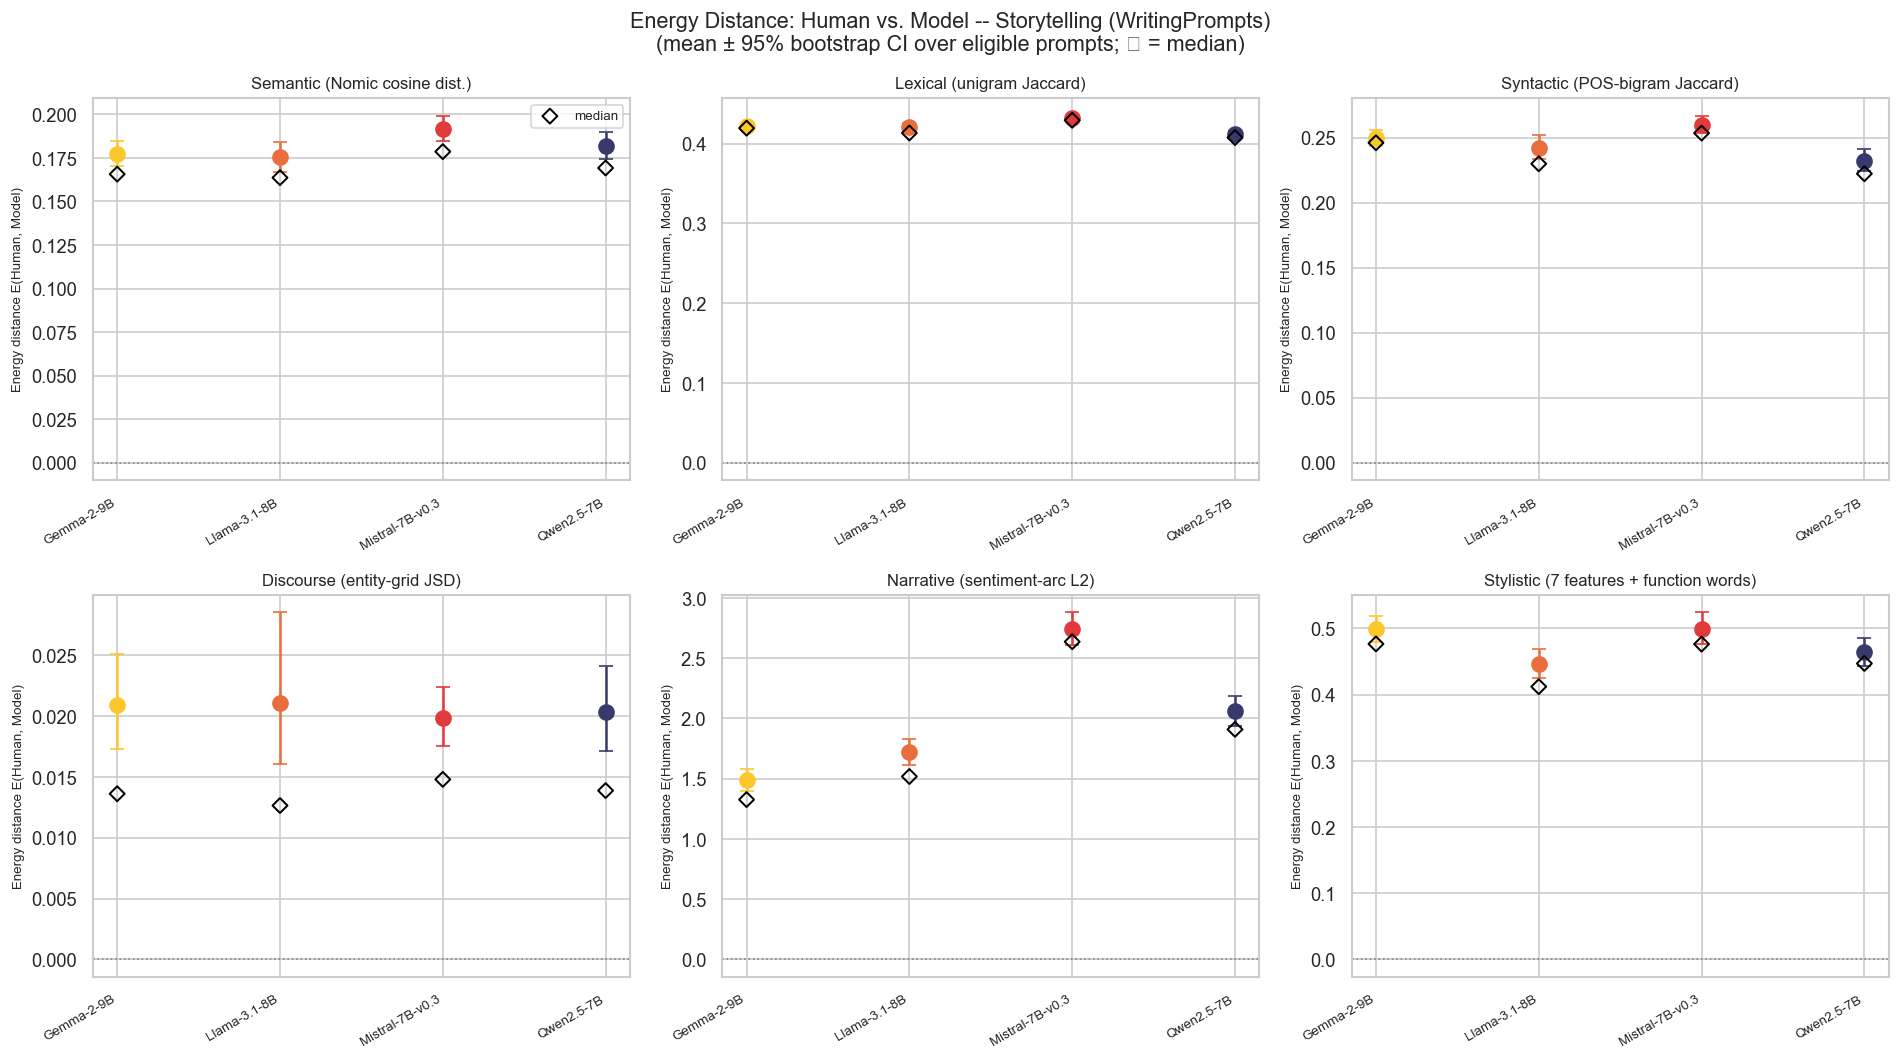

In [119]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, metric in zip(axes, PAIRING_METRICS):
    sub = df_energy_summary[df_energy_summary.metric == metric].set_index('source')
    order = [mk for mk in MODEL_SOURCES if mk in sub.index]
    ax.axhline(0, color='grey', linewidth=1, linestyle=':')
    for xi, mk in enumerate(order):
        row = sub.loc[mk]
        c = MODEL_COLORS[MODEL_LABELS[mk]]
        yerr = [[max(row['mean'] - row['ci_lo'], 0)], [max(row['ci_hi'] - row['mean'], 0)]]
        ax.errorbar(xi, row['mean'], yerr=yerr, fmt='o', color=c, markersize=9,
                    capsize=4, linewidth=1.5, zorder=3)
        ax.scatter(xi, row['median'], marker='D', s=40, facecolors='none', edgecolors='black',
                   linewidth=1.2, zorder=4, label='median' if (ax is axes[0] and xi == 0) else None)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([MODEL_LABELS[mk] for mk in order], rotation=30, ha='right', fontsize=8)
    ax.set_title(METRIC_LABELS[metric], fontsize=10)
    ax.set_ylabel('Energy distance E(Human, Model)', fontsize=8)

axes[0].legend(fontsize=8, loc='best')
fig.suptitle('Energy Distance: Human vs. Model -- Storytelling (WritingPrompts)\n'
             '(mean \u00b1 95% bootstrap CI over eligible prompts; \u25c7 = median)',
             fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'energy_distance_per_metric.png', dpi=150, bbox_inches='tight')
plt.show()


## Length Robustness Check (Human-Relative Location)

1. **Length gap:** does mean text length differ between Human and each model, per `ref_prompts`?
2. **Split-matched length confounds (`delta_L`, `energy_L`):** length-only analogues of `delta` and `energy_dist`


In [120]:
from metrics.metrics_lib.baseline import word_tokenize_simple

# Compute the mean text length (in tokens)
def _mean_len(texts):

    lens = [len(word_tokenize_simple(t)) for t in texts]
    return float(np.mean(lens)) if lens else np.nan


rows_len = []

# Compute the mean text length and number of texts for each prompt ID and source (human or model)
for pid in ref_prompts:
    hum = human_stories_by_prompt[pid]
    rows_len.append({'prompt_id': pid, 'source': 'human', 'mean_len': _mean_len(hum), 'n_texts': len(hum)})

    # For each model source, retrieve the corresponding texts for the current prompt ID
    for mk in MODEL_SOURCES:
        mt = model_texts.get((mk, pid), [])
        rows_len.append({'prompt_id': pid, 'source': mk, 'mean_len': _mean_len(mt), 'n_texts': len(mt)})

# Create a DataFrame from the rows of text length statistics and export it to a CSV file.
df_length = pd.DataFrame(rows_len)
df_length.to_csv(PAIRING_DIR / 'text_length_per_prompt.csv', index=False)

print(f'Text length computed for {len(ref_prompts)} ref_prompts x {1 + len(MODEL_SOURCES)} sources '
      f'-> text_length_per_prompt.csv')
df_length.groupby('source')['mean_len'].describe().reindex(SOURCE_ORDER).round(1)


Text length computed for 199 ref_prompts x 5 sources -> text_length_per_prompt.csv


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
human,199.0,539.2,202.4,120.2,392.9,528.0,674.7,1264.8
gemma,199.0,474.2,54.1,154.4,449.6,477.8,504.9,621.4
llama,199.0,498.3,54.8,97.6,480.6,497.0,518.2,902.0
mistral,199.0,562.2,65.8,152.6,528.1,561.8,598.3,755.0
qwen,199.0,546.1,84.3,50.2,507.5,552.2,595.1,715.2


### Length Confound (`delta_L`, `energy_L`)


In [121]:
# Length "distance matrix" per ref_prompt: |len_i - len_j| over [human | model_1 | ...],
# same segment order as segments_by_prompt (and pairing_matrices above)
length_matrices = {}
for pid in ref_prompts:
    segs = segments_by_prompt[pid]
    lens = np.array([len(word_tokenize_simple(t)) for _, seg_texts in segs for t in seg_texts], dtype=float)
    length_matrices[pid] = np.abs(lens[:, None] - lens[None, :])

print(f'Length-distance matrices built for {len(length_matrices)} ref_prompts (REF_SIZE={REF_SIZE})')


Length-distance matrices built for 199 ref_prompts (REF_SIZE=3)


In [122]:
# delta_L: identical to Matched Reference/Control Split and Delta to Human Control
# above, rerun on length_matrices instead of a diversity-metric matrix.
rows_split_len = []
for pid in ref_prompts:

    # Retrieve the length distance matrix and segments for the current prompt ID
    D_len = length_matrices[pid]
    segs = segments_by_prompt[pid]
    n_human = len(segs[0][1])

    # Compute the slices for the human and model groups based on the lengths of the segments
    slices = slices_from_lengths([(s, len(t)) for s, t in segs])
    model_slices = {s: sl for s, sl in slices.items() if s != 'human'}

    # For each split ID and corresponding bands obtained from the reference_control_splits function, 
    # compute the distances and store them in the rows_split_len list.
    for split_id, bands in reference_control_splits(D_len, n_human, model_slices, REF_SIZE):
        ctrl_arr = bands.pop('human-human')
        rows_split_len.extend({'prompt_id': pid, 'split_id': split_id, 'source': 'human',
                               'pairing': 'human-human', 'dist': float(d)} for d in ctrl_arr)
        
        for src, arr in bands.items():
            rows_split_len.extend({'prompt_id': pid, 'split_id': split_id, 'source': src,
                                   'pairing': 'human-model', 'dist': float(d)} for d in arr)


# Create a DataFrame from the rows of length split distances and export it to a CSV file
df_split_len_long = pd.DataFrame(rows_split_len)
df_split_len_long.to_csv(PAIRING_DIR / 'length_split_distances_long.csv', index=False)


# Compute the mean distances for the control (human-human) and model (human-model) pairings, grouped by prompt ID, split ID and source
ctrl_mean_len = (df_split_len_long[df_split_len_long.pairing == 'human-human']
                 .groupby(['prompt_id', 'split_id'])['dist'].mean().rename('ctrl_mean'))
model_mean_len = (df_split_len_long[df_split_len_long.pairing == 'human-model']
                  .groupby(['prompt_id', 'split_id', 'source'])['dist'].mean().rename('model_mean'))

# Merge the control and model mean distances on prompt ID and split ID and compute the delta_L 
df_delta_L_split = model_mean_len.reset_index().merge(
    ctrl_mean_len.reset_index(), on=['prompt_id', 'split_id'], how='inner')
df_delta_L_split['delta_L'] = df_delta_L_split['model_mean'] - df_delta_L_split['ctrl_mean']


# Compute the mean delta_L for each source and prompt ID, grouped by source and prompt ID
df_delta_L_prompt = (df_delta_L_split.groupby(['source', 'prompt_id'])['delta_L']
                     .mean().reset_index())
df_delta_L_prompt.to_csv(PAIRING_DIR / 'length_delta_L_per_prompt.csv', index=False)


# Compute the number of splits for each source and prompt ID, grouped by source and prompt ID
n_splits_len = df_delta_L_split.groupby(['source', 'prompt_id']).size()
print(f'{len(df_delta_L_prompt)} (model, prompt) delta_L values, splits/prompt averaged: '
      f'{sorted(n_splits_len.unique())} -> length_delta_L_per_prompt.csv')
df_delta_L_prompt.groupby('source')['delta_L'].describe().round(3)


796 (model, prompt) delta_L values, splits/prompt averaged: [np.int64(10)] -> length_delta_L_per_prompt.csv


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
gemma,199.0,-78.472,109.402,-314.20,-143.90,-85.48,-28.620,337.6
llama,199.0,-72.577,125.404,-310.20,-152.42,-87.88,-26.900,590.8
mistral,199.0,-60.734,127.246,-318.28,-134.90,-75.44,-0.425,476.6
qwen,199.0,-63.487,126.315,-317.92,-145.66,-79.96,-2.700,476.6


In [123]:
# energy_L: identical construction to the Energy Distance section above 
rows_energy_len = []
for pid in ref_prompts:

    # Retrieve the length distance matrix and segments for the current prompt ID
    D_len = length_matrices[pid]
    segs = segments_by_prompt[pid]

    # Compute the slices for the human and model groups based on the lengths of the segments
    slices = slices_from_lengths([(s, len(t)) for s, t in segs])
    idx_h = np.arange(*slices['human'])

    # For each model source in the segments, compute the energy distance between the human and model groups
    for src, _ in segs[1:]:
        idx_m = np.arange(*slices[src])
        try:
            e_obs, _, _ = energy_distance_hm(D_len, idx_h, idx_m)
        except ValueError:
            e_obs = np.nan
            
        rows_energy_len.append({'prompt_id': pid, 'source': src, 'energy_L': e_obs})

df_energy_L_prompt = pd.DataFrame(rows_energy_len)
df_energy_L_prompt.to_csv(PAIRING_DIR / 'length_energy_L_per_prompt.csv', index=False)

print(f'{len(df_energy_L_prompt)} (model, prompt) energy_L values -> length_energy_L_per_prompt.csv')
df_energy_L_prompt.groupby('source')['energy_L'].describe().round(3)


796 (model, prompt) energy_L values -> length_energy_L_per_prompt.csv


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
gemma,199.0,220.605,145.794,24.16,118.60,182.48,281.12,996.08
llama,199.0,233.030,168.771,10.64,125.00,188.88,298.16,1189.16
mistral,199.0,221.796,150.215,28.80,122.80,180.83,287.36,909.20
qwen,199.0,212.433,144.784,4.00,107.88,185.28,287.04,892.16


### Length vs. Location Correlation

Spearman correlation between each location metric and its split-matched length-only counterpart, per `(metric, model)`, over `ref_prompts`: `delta` vs. `delta_L` and `energy_dist` vs. `energy_L`.


In [124]:
from scipy.stats import spearmanr

# Compute the Spearman correlation between text length and the delta or energy metrics for each metric and model source
def _length_confound_table(df_metric_prompt, value_col, cov_df, cov_col, out_name):
    # Spearman rho(cov_col, value_col), per (metric, model), over ref_prompts.
    rows = []
    for metric in PAIRING_METRICS:
        for mk in MODEL_SOURCES:
            sub = df_metric_prompt[(df_metric_prompt.metric == metric) & (df_metric_prompt.source == mk)]
            merged = sub.merge(cov_df[['prompt_id', 'source', cov_col]],
                               on=['prompt_id', 'source'], how='inner').dropna(subset=[value_col, cov_col])
            
            if len(merged) < 5:
                continue

            rho, p = spearmanr(merged[cov_col], merged[value_col])
            rows.append({'metric': metric, 'source': mk, 'model': MODEL_LABELS[mk],
                        'rho_length': rho, 'p_length': p, 'n': len(merged)})
            
    df = pd.DataFrame(rows)
    df.to_csv(PAIRING_DIR / f'length_confound_{out_name}.csv', index=False)
    return df


df_length_confound_delta = _length_confound_table(
    df_delta_prompt, 'delta', df_delta_L_prompt, 'delta_L', 'delta')

df_length_confound_energy = _length_confound_table(
    df_energy_per_prompt, 'energy_dist', df_energy_L_prompt, 'energy_L', 'energy')

_model_order = [MODEL_LABELS[m] for m in MODEL_SOURCES]
print('Spearman rho(delta_L, delta): Delta to Human Control, per (metric, model):')
display(df_length_confound_delta.pivot(index='model', columns='metric', values='rho_length')
       .reindex(_model_order).round(3))

print('\nSpearman rho(energy_L, energy_dist): Energy Distance, per (metric, model):')
display(df_length_confound_energy.pivot(index='model', columns='metric', values='rho_length')
       .reindex(_model_order).round(3))


Spearman rho(delta_L, delta): Delta to Human Control, per (metric, model):


metric,D_disc,D_lex,D_narr,D_sem,D_style,D_syn
model,,,,,,
Gemma-2-9B,0.074,0.244,-0.178,0.278,-0.061,-0.006
Llama-3.1-8B,-0.060,0.268,-0.251,0.333,-0.072,-0.024
Mistral-7B-v0.3,-0.231,0.070,-0.320,0.258,-0.179,-0.148
Qwen2.5-7B,-0.151,0.260,-0.295,0.303,-0.139,-0.118



Spearman rho(energy_L, energy_dist): Energy Distance, per (metric, model):


metric,D_disc,D_lex,D_narr,D_sem,D_style,D_syn
model,,,,,,
Gemma-2-9B,0.206,0.148,0.037,0.246,0.136,0.250
Llama-3.1-8B,0.284,0.169,0.131,0.195,0.059,0.318
Mistral-7B-v0.3,0.315,0.091,0.016,0.222,-0.030,0.236
Qwen2.5-7B,0.353,0.238,0.068,0.268,0.118,0.346


## Length-Adjusted Sensitivity Analysis (delta vs. delta_L)

Does accounting for `delta_L` shift the direction or magnitude of the model-specific `delta` pattern

For each dimension, a no-intercept OLS on prompt-level `delta`:

$$\text{delta} = \sum_{m} \beta_m \cdot \mathbb{1}[\text{source}=m] + \beta_{L} \cdot (\text{delta\_L} - \overline{\text{delta\_L}}) + \varepsilon$$

- `delta_L` is centered within each dimension's own regression sample
- No intercept (`0 + C(source) + delta_L_c`): each `beta_m` is directly the length-adjusted mean `delta` for that model, evaluated at the sample's average `delta_L`
- **Prompt-clustered standard errors** (`cov_type='cluster'`, grouped by `prompt_id`), since each prompt contributes one observation per model and these are not independent draws
- Compared directly against the unadjusted per-model mean `delta` (same regression sample) to see whether adjusting for length changes sign or magnitude


In [125]:
import statsmodels.formula.api as smf

# Length-adjusted sensitivity analysis: linear regression of delta ~ source + delta_L, per metric.
df_delta_sens = df_delta_prompt.merge(
    df_delta_L_prompt[['prompt_id', 'source', 'delta_L']],
    on=['prompt_id', 'source'], how='inner',
).dropna(subset=['delta', 'delta_L'])

sens_rows = []
for metric in PAIRING_METRICS:
    sub = df_delta_sens[df_delta_sens.metric == metric].copy()

    # If there are fewer than 2 unique sources or fewer than 20 rows of data for this metric, 
    # skip the regression analysis and print a message indicating that there is insufficient data for regression.
    if sub['source'].nunique() < 2 or len(sub) < 20:
        print(f'{metric}: skipped -- insufficient data for regression')
        continue

    # Center delta_L within this metric's own regression sample
    sub['delta_L_c'] = sub['delta_L'] - sub['delta_L'].mean()

    # Fit an ordinary least squares (OLS) regression model 
    model = smf.ols('delta ~ 0 + C(source) + delta_L_c', data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['prompt_id']})
    ci = model.conf_int()

    # Extract the coefficient and p-value for the centered delta_L variable from the regression model
    length_coef = model.params.get('delta_L_c', np.nan)
    length_p = model.pvalues.get('delta_L_c', np.nan)

    for term in model.params.index:
        if not term.startswith('C(source)['):
            continue

        # Extract the model key (mk) from the term name and compute the unadjusted mean delta for this source
        mk = term[len('C(source)['):-1]
        unadj_mean = sub.loc[sub.source == mk, 'delta'].mean()
        adj_mean = model.params[term]

        sens_rows.append({
            'metric': metric, 'source': mk, 'model': MODEL_LABELS[mk],
            'n': int((sub.source == mk).sum()),
            'unadj_mean_delta': unadj_mean,
            'adj_mean_delta': adj_mean,
            'adj_ci_lo': ci.loc[term, 0], 'adj_ci_hi': ci.loc[term, 1],
            'shift': adj_mean - unadj_mean,
            'length_coef': length_coef, 'length_p': length_p,
        })

df_delta_sensitivity = pd.DataFrame(sens_rows)
df_delta_sensitivity.to_csv(PAIRING_DIR / 'delta_length_sensitivity.csv', index=False)

print(f'Length-adjusted sensitivity analysis ({len(df_delta_sensitivity)} rows) -> '
      f'delta_length_sensitivity.csv')

_model_order = [MODEL_LABELS[m] for m in MODEL_SOURCES]
print('\nUnadjusted mean delta:')
display(df_delta_sensitivity.pivot(index='model', columns='metric', values='unadj_mean_delta')
       .reindex(_model_order).round(4))

print('\nLength-adjusted mean delta (at average delta_L):')
display(df_delta_sensitivity.pivot(index='model', columns='metric', values='adj_mean_delta')
       .reindex(_model_order).round(4))

print('\nShift (adjusted - unadjusted):')
display(df_delta_sensitivity.pivot(index='model', columns='metric', values='shift')
       .reindex(_model_order).round(4))


Length-adjusted sensitivity analysis (24 rows) -> delta_length_sensitivity.csv

Unadjusted mean delta:


metric,D_disc,D_lex,D_narr,D_sem,D_style,D_syn
model,,,,,,
Gemma-2-9B,-0.0143,0.0203,0.0402,-0.0188,0.0273,-0.0081
Llama-3.1-8B,-0.0137,0.0119,0.1767,-0.0217,0.0108,-0.0121
Mistral-7B-v0.3,-0.0140,0.0145,0.5626,-0.0186,0.0343,-0.0060
Qwen2.5-7B,-0.0137,0.0114,0.2710,-0.0139,0.0222,-0.0178



Length-adjusted mean delta (at average delta_L):


metric,D_disc,D_lex,D_narr,D_sem,D_style,D_syn
model,,,,,,
Gemma-2-9B,-0.0144,0.0205,0.0302,-0.0180,0.0265,-0.0081
Llama-3.1-8B,-0.0137,0.0120,0.1726,-0.0214,0.0105,-0.0120
Mistral-7B-v0.3,-0.0139,0.0143,0.5714,-0.0193,0.0349,-0.0060
Qwen2.5-7B,-0.0137,0.0112,0.2762,-0.0143,0.0226,-0.0179



Shift (adjusted - unadjusted):


metric,D_disc,D_lex,D_narr,D_sem,D_style,D_syn
model,,,,,,
Gemma-2-9B,-0.0,0.0003,-0.0100,0.0008,-0.0007,0.0001
Llama-3.1-8B,-0.0,0.0001,-0.0041,0.0003,-0.0003,0.0000
Mistral-7B-v0.3,0.0,-0.0002,0.0088,-0.0007,0.0006,-0.0001
Qwen2.5-7B,0.0,-0.0002,0.0052,-0.0005,0.0004,-0.0000
